# Step 3 — Geometry of compiled RASP programs

Run this notebook in order using the repository's Python environment.
Install progress support in that environment with `%pip install tqdm` if needed.
Progress bars show completed work, elapsed time, and estimated remaining time.
Compilation and matrix operations advance the bar when the current operation finishes.
It loads the 12 existing programs and adds the focused A/B examples.
Step 2's forward-pass sanity check is the prerequisite for interpreting these results.

**Sampling:** separate probes for each program, with exactly the same number of
observations for every reachable output class at the selected sequence length.
Sampling uses the RASP evaluator's labels; the real model's labels must agree.
Repeated examples retain their sampling weight.

**Observation:** each probe specifies an input sequence and one target token
position. Only that target's residual becomes a row. BOS is excluded and PAD is
never used. Within each program, every stage uses the same rows in the same order.

**Stages:** embeddings, then residuals after every attention block and every MLP.
`Lk/MLP` is the end of full Transformer layer k. Disabled blocks are included.

**Views:** `full` uses the entire residual stream; `computed` removes token,
position, and constant-one lanes. Features are centered, without whitening or
per-feature standardization. This preserves the compiled model's feature scales.

For covariance eigenvalues lambda, explained variance is lambda / sum(lambda),
and participation ratio is sum(lambda)^2 / sum(lambda^2).
Centered linear CKA is ||X.T @ Y||_F^2 / (||X.T @ X||_F ||Y.T @ Y||_F),
following [Kornblith et al. (2019)](https://proceedings.mlr.press/v97/kornblith19a.html).

Programs have different probe distributions, so cross-program summaries are
descriptive comparisons under each program's output-balanced distribution.
Zero-variance stages have undefined CKA (shown in gray). Their PCA spectrum and
participation ratio are recorded as zero by convention. Probe results describe
the selected input distribution; participation ratio is not a variable count.

In [1]:
%matplotlib inline 

In [2]:
from pathlib import Path
from collections import OrderedDict
from importlib.metadata import version, distribution
import ast
import json
import sys
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import jax
import jax.numpy as jnp
from IPython.display import display
from tqdm.auto import tqdm
from tracr.rasp import rasp
from tracr.compiler import compiling, lib

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

start = Path.cwd().resolve()
NOTEBOOK_DIR = next(
    (p for root in (start, *start.parents)
     for p in (root, root / "notebooks")
     if (p / "programs.ipynb").exists()), None
)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Cannot locate notebooks/programs.ipynb")

# Read configuration and RASP assignments, stopping at the PROGRAMS registry.
source_nb = json.loads((NOTEBOOK_DIR / "programs.ipynb").read_text())
scope = {"rasp": rasp, "lib": lib}
config_names = {"VOCAB", "MAX_SEQ_LEN", "CASUAL", "CAUSAL",
                "BOS", "PAD", "MLP_EXACTNESS"}
for cell in source_nb["cells"]:
    if cell["cell_type"] != "code":
        continue
    tree = ast.parse("".join(cell["source"]))
    for node in tree.body:
        if not isinstance(node, (ast.Assign, ast.AnnAssign)):
            continue
        targets = node.targets if isinstance(node, ast.Assign) else [node.target]
        names = {part.id for target in targets for part in ast.walk(target)
                 if isinstance(part, ast.Name)}
        value_names = {part.id for part in ast.walk(node.value)
                       if isinstance(part, ast.Name)}
        if names & config_names or "PROGRAMS" in names or value_names & {"rasp", "lib"}:
            module = ast.Module(body=[node], type_ignores=[])
            exec(compile(module, "programs.ipynb definitions", "exec"), scope)
    if "PROGRAMS" in scope:
        break

VOCAB = sorted(scope["VOCAB"])
MAX_SEQ_LEN = scope["MAX_SEQ_LEN"]
BOS, PAD = scope["BOS"], scope["PAD"]
CAUSAL = scope.get("CAUSAL", scope.get("CASUAL", False))
MLP_EXACTNESS = scope["MLP_EXACTNESS"]
PROGRAMS = dict(scope["PROGRAMS"])

previous_or_self = rasp.Select(
    rasp.indices, rasp.indices,
    lambda key, query: key == query - 1 or (query == 0 and key == 0)
).named("previous_or_self")
PROGRAMS["A_prev_token_class"] = rasp.Aggregate(
    previous_or_self, rasp.tokens
).named("prev_token_class")
histogram = lib.make_hist().named("histogram")
PROGRAMS["B_histogram_then_repeated_class"] = rasp.Map(
    lambda count: 1 if count > 1 else 0, histogram
).named("repeated_class")

print(f"Loaded {len(PROGRAMS)} programs from {NOTEBOOK_DIR}")

Loaded 14 programs from /Users/raghul/RaspFormer/notebooks


## 1. Balanced probes

Defaults select 64 target observations per output class, at sequence length six.
The candidate pool includes random, constant, alternating, palindrome, unique,
ordered, and count-controlled inputs. Each program receives its own probes.

The output domains below follow the 14 programs' definitions at this fixed length;
the notebook stops if a reachable class is missing from the candidate pool.
For each class, target positions are sampled as evenly as their reachability allows.
Classes can require particular positions: for example, the smallest token-plus-index
output can occur only at index zero.

Rare classes can require sampling with replacement. The audit reports unique
input/position pairs as well as observation counts. To study length effects,
rerun with a different `PROBE_LENGTH`; each run has its own export folder.

Balanced probes:   0%|          | 0/14 [00:00<?, ?program/s]

P01_absolute: RASP evaluation:   0%|          | 0/3383 [00:00<?, ?sequence/s]

P01_absolute: 6 classes × 64 = 384 targets


P02_index_parity: RASP evaluation:   0%|          | 0/3383 [00:00<?, ?sequence/s]

P02_index_parity: 2 classes × 64 = 128 targets


...

A_prev_token_class: 8 classes × 64 = 512 targets


B_histogram_then_repeated_class: RASP evaluation:   0%|          | 0/3383 [00:00<?, ?sequence/s]

B_histogram_then_repeated_class: 2 classes × 64 = 128 targets


,program,output_class,observations,unique_sequences,unique_targets
0,P01_absolute,0,64,64,64
1,P01_absolute,1,64,64,64
2,P01_absolute,2,64,62,64
3,P01_absolute,3,64,63,64
4,P01_absolute,4,64,62,64
...,...,...,...,...,...
96,A_prev_token_class,3,64,64,64
97,A_prev_token_class,4,64,63,64
98,A_prev_token_class,5,64,63,64
99,B_histogram_then_repeated_class,0,64,62,64


Candidate pool: 3383 unique sequences


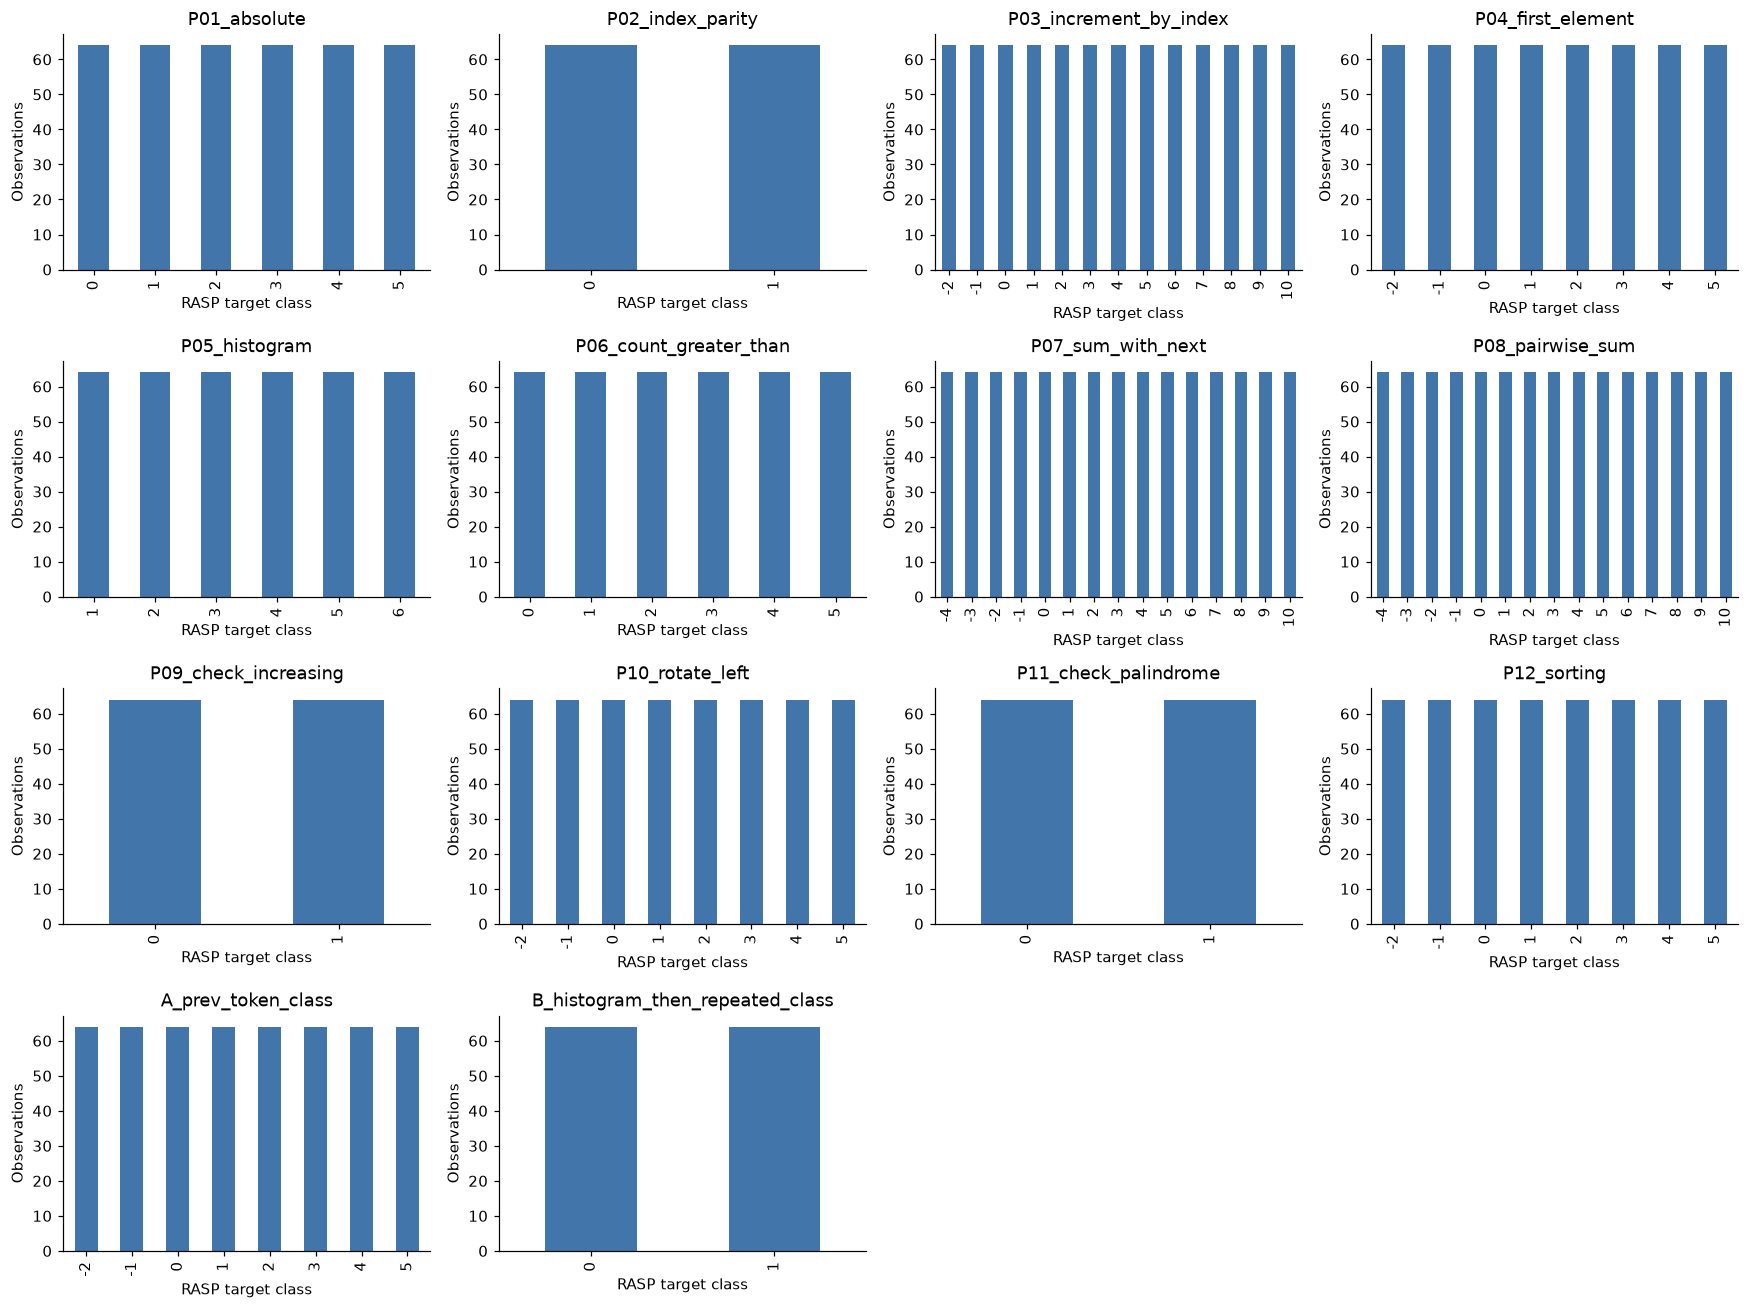

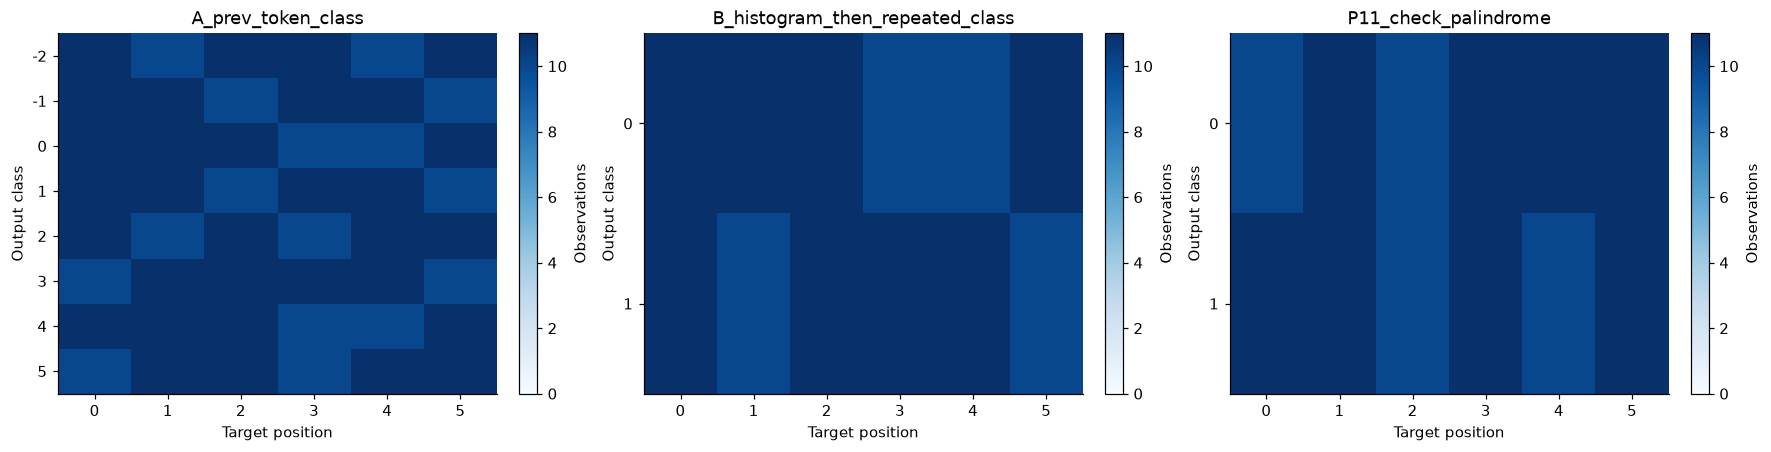

In [3]:
SEED = 42
PROBE_LENGTH = MAX_SEQ_LEN
SAMPLES_PER_CLASS = 64
RANDOM_CANDIDATES = 2048
STRUCTURED_CANDIDATES = 128

if not 2 <= PROBE_LENGTH <= min(MAX_SEQ_LEN, len(VOCAB)):
    raise ValueError("This probe design requires length 2..min(MAX_SEQ_LEN, vocabulary size).")
if SAMPLES_PER_CLASS < 1:
    raise ValueError("SAMPLES_PER_CLASS must be positive.")

rng = np.random.default_rng(SEED)
alphabet = np.asarray(VOCAB)
K, L = len(alphabet), PROBE_LENGTH
candidate_map = {}

def add_candidate(tokens, family):
    key = tuple(int(v) for v in tokens)
    candidate_map.setdefault(key, family)

for a in VOCAB:
    add_candidate([a] * L, "constant")
    for b in VOCAB:
        add_candidate([a if p % 2 == 0 else b for p in range(L)], "alternating")
        if a != b:
            for count in range(1, L):
                base = [a] * count + [b] * (L - count)
                for shift in range(L):
                    add_candidate(np.roll(base, shift), "count_controlled")

for _ in range(RANDOM_CANDIDATES):
    add_candidate(rng.choice(alphabet, size=L), "random")
for _ in range(STRUCTURED_CANDIDATES):
    values = rng.choice(alphabet, size=L)
    add_candidate(np.sort(values), "increasing")
    add_candidate(np.sort(values)[::-1], "decreasing")
    add_candidate(rng.choice(alphabet, size=L, replace=False), "unique")
    half = rng.choice(alphabet, size=(L + 1) // 2)
    mirror = half[::-1] if L % 2 == 0 else half[-2::-1]
    add_candidate(np.concatenate([half, mirror]), "palindrome")

CANDIDATES = [list(tokens) for tokens in candidate_map]
CANDIDATE_FAMILIES = list(candidate_map.values())
sum_classes = sorted({a + b for a in VOCAB for b in VOCAB})
EXPECTED_CLASSES = {
    "P01_absolute": sorted({abs(v) for v in VOCAB}),
    "P02_index_parity": sorted({p % 2 for p in range(L)}),
    "P03_increment_by_index": sorted({v + p for v in VOCAB for p in range(L)}),
    "P04_first_element": VOCAB,
    "P05_histogram": list(range(1, L + 1)),
    "P06_count_greater_than": list(range(L)),
    "P07_sum_with_next": sum_classes,
    "P08_pairwise_sum": sum_classes,
    "P09_check_increasing": [0, 1],
    "P10_rotate_left": VOCAB,
    "P11_check_palindrome": [0, 1],
    "P12_sorting": VOCAB,
    "A_prev_token_class": VOCAB,
    "B_histogram_then_repeated_class": [0, 1],
}

evaluator = rasp.DefaultRASPEvaluator()
PROBES, OBSERVATIONS = {}, {}
audit_rows = []
probe_progress = tqdm(PROGRAMS.items(), desc="Balanced probes", unit="program")
for program_index, (name, program) in enumerate(probe_progress):
    probe_progress.set_postfix_str(name)
    expected_classes = EXPECTED_CLASSES[name]
    buckets = {label: {} for label in expected_classes}
    for candidate_id, tokens in enumerate(tqdm(
        CANDIDATES, desc=f"{name}: RASP evaluation", unit="sequence", leave=False
    )):
        outputs = evaluator.evaluate(program, tokens)
        for position, value in enumerate(outputs):
            if value not in buckets:
                raise ValueError(f"{name}: unexpected output class {value}")
            buckets[value].setdefault(position, []).append(candidate_id)
    missing = [label for label, positions in buckets.items() if not positions]
    if missing:
        raise ValueError(f"{name}: candidate pool misses output classes {missing}")

    sample_rng = np.random.default_rng(SEED + 1009 * program_index)
    records = []
    for label, positions in buckets.items():
        available = sample_rng.permutation(sorted(positions))
        quotient, remainder = divmod(SAMPLES_PER_CLASS, len(available))
        for j, position in enumerate(available):
            quota = quotient + (j < remainder)
            choices = positions[position]
            selected = sample_rng.choice(choices, size=quota, replace=len(choices) < quota)
            for candidate_id in selected:
                tokens = CANDIDATES[candidate_id]
                records.append({"candidate_id": int(candidate_id), "position": int(position),
                                "target_class": int(label), "token": tokens[position],
                                "family": CANDIDATE_FAMILIES[candidate_id], "tokens": tokens})
    records = [records[i] for i in sample_rng.permutation(len(records))]
    table = pd.DataFrame(records)
    table.insert(0, "probe_id", range(len(table)))
    OBSERVATIONS[name] = table
    PROBES[name] = table.tokens.tolist()
    for label, group in table.groupby("target_class"):
        audit_rows.append({"program": name, "output_class": label, "observations": len(group),
                           "unique_sequences": group.candidate_id.nunique(),
                           "unique_targets": len(group[["candidate_id", "position"]].drop_duplicates())})
    tqdm.write(f"{name}: {len(expected_classes)} classes × {SAMPLES_PER_CLASS} = {len(table)} targets")

BALANCE_AUDIT = pd.DataFrame(audit_rows)
RUN_DIR = NOTEBOOK_DIR / "results" / "geometry" / f"output_balanced_L{L}_seed{SEED}_n{SAMPLES_PER_CLASS}"
FIGURE_DIR = RUN_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
display(BALANCE_AUDIT)
print(f"Candidate pool: {len(CANDIDATES)} unique sequences")

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, (name, table) in zip(axes.flat, OBSERVATIONS.items()):
    table.target_class.value_counts().sort_index().plot.bar(ax=ax, color="#4276ab")
    ax.set(title=name, xlabel="RASP target class", ylabel="Observations")
for ax in list(axes.flat)[len(PROGRAMS):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "output_class_balance.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
for ax, name in zip(axes, ("A_prev_token_class", "B_histogram_then_repeated_class", "P11_check_palindrome")):
    table = OBSERVATIONS[name]
    counts = pd.crosstab(table.target_class, table.position).reindex(columns=range(L), fill_value=0)
    im = ax.imshow(counts.to_numpy(), aspect="auto", cmap="Blues", vmin=0)
    ax.set(title=name, xticks=range(L), xlabel="Target position",
           yticks=range(len(counts)), yticklabels=counts.index, ylabel="Output class")
    fig.colorbar(im, ax=ax, label="Observations")
fig.savefig(FIGURE_DIR / "class_position_balance.png", bbox_inches="tight")
plt.show()

## 2. Compile and collect real model activations

All probes have the same length, so the model's batched forward function can be
JIT compiled. This collects the assembled Transformer's actual activations.
The first JAX call for each model includes compilation time.

Compile + activations:   0%|          | 0/14 [00:00<?, ?program/s]

P01_absolute: 3 stages, width=22, computed lanes=6; 1.2s
P02_index_parity: 3 stages, width=19, computed lanes=2; 0.8s
P03_increment_by_index: 3 stages, width=30, computed lanes=13; 0.7s
P04_first_element: 3 stages, width=25, computed lanes=8; 1.0s
P05_histogram: 3 stages, width=25, computed lanes=8; 1.1s
P06_count_greater_than: 3 stages, width=25, computed lanes=8; 0.1s
P07_sum_with_next: 7 stages, width=55, computed lanes=38; 1.1s
P08_pairwise_sum: 7 stages, width=54, computed lanes=37; 1.0s
P09_check_increasing: 7 stages, width=37, computed lanes=20; 1.0s
P10_rotate_left: 7 stages, width=39, computed lanes=22; 1.1s
P11_check_palindrome: 13 stages, width=69, computed lanes=52; 1.0s
P12_sorting: 7 stages, width=81, computed lanes=64; 1.0s
A_prev_token_class: 3 stages, width=25, computed lanes=8; 0.1s
B_histogram_then_repeated_class: 5 stages, width=27, computed lanes=10; 1.1s


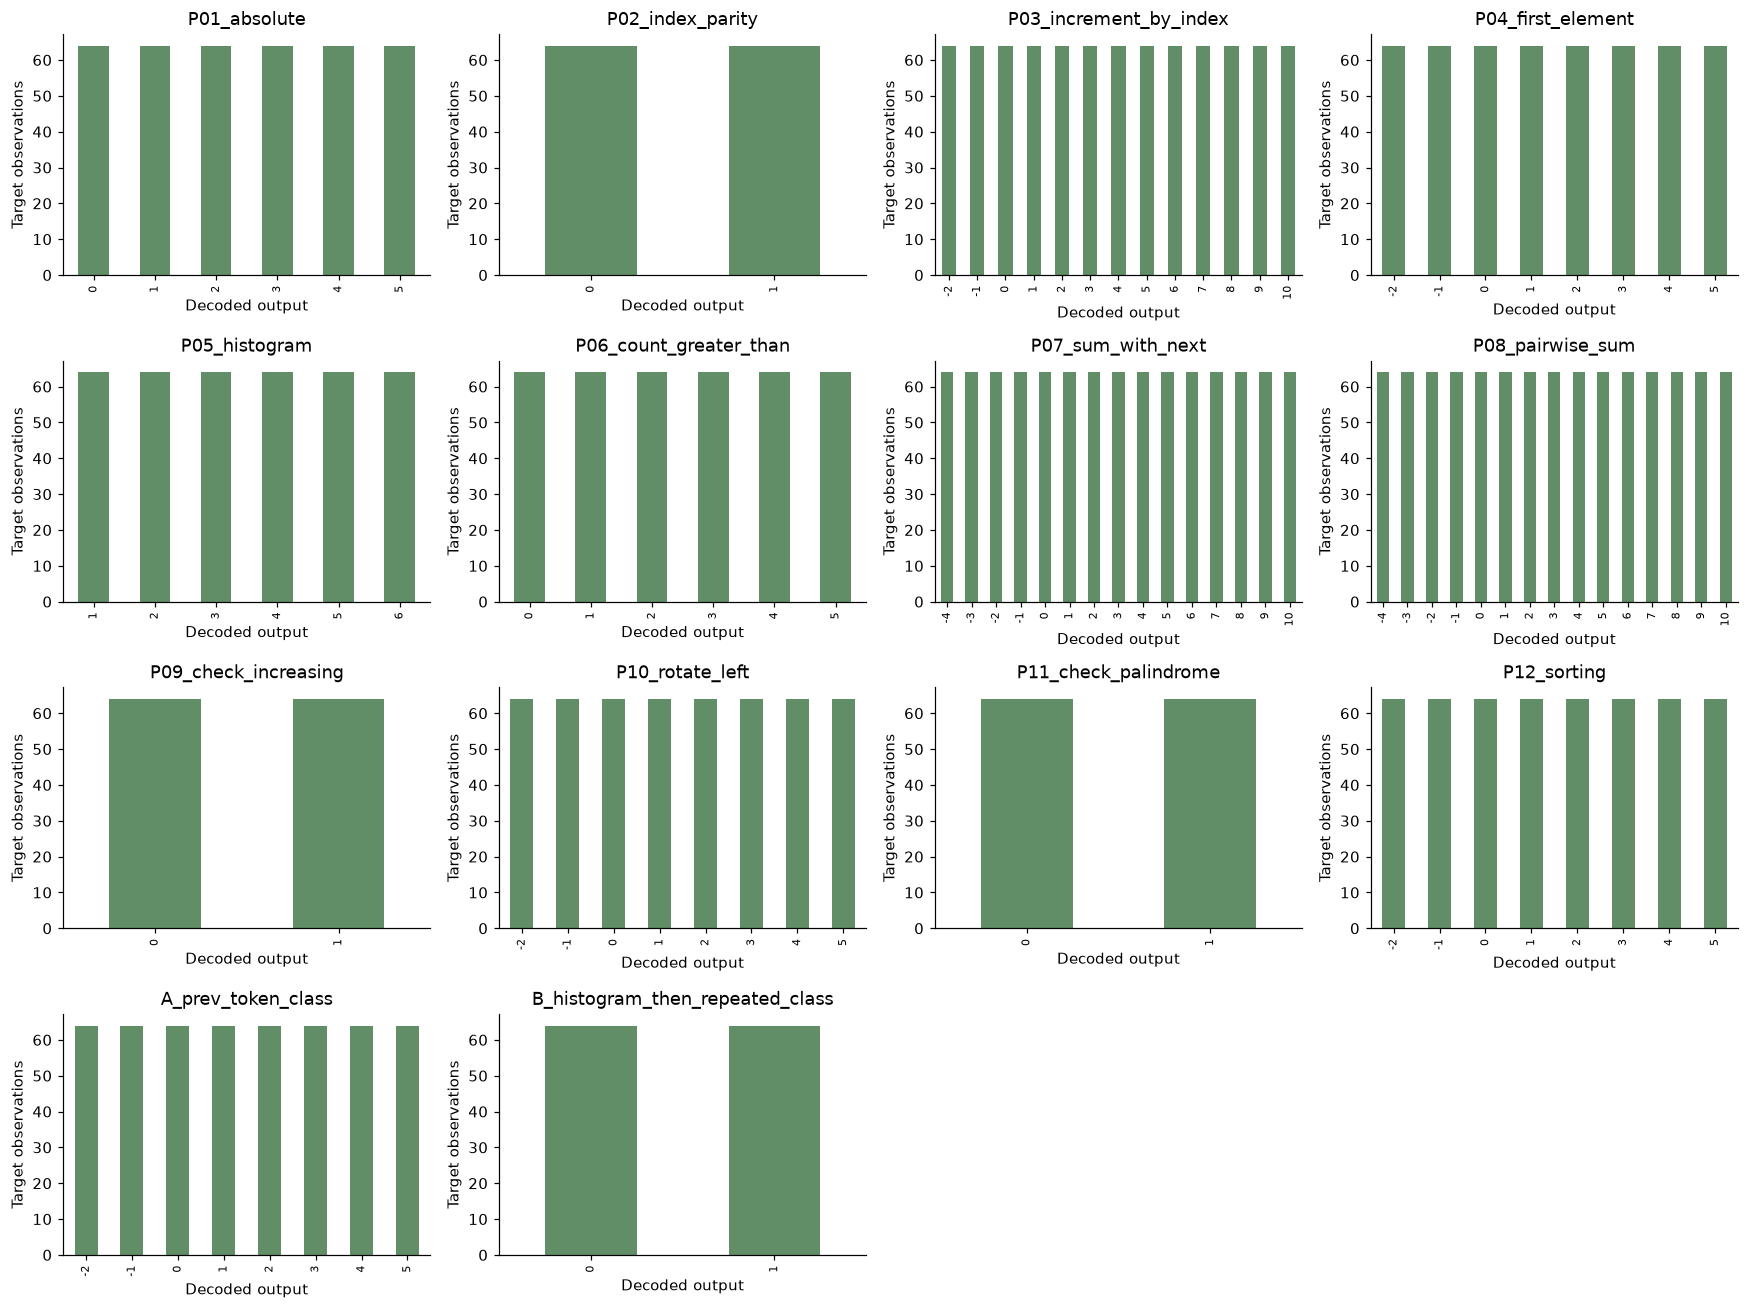

In [4]:
MODELS = {}
ACTIVATIONS = {}
OUTPUT_LABELS = {}
VIEW_COLUMNS = {}

model_progress = tqdm(PROGRAMS.items(), desc="Compile + activations", unit="program")
for name, program in model_progress:
    started = perf_counter()
    model_progress.set_postfix_str(f"{name}: Tracr compilation", refresh=True)
    model = compiling.compile_rasp_to_model(
        program, vocab=set(VOCAB), max_seq_len=MAX_SEQ_LEN,
        causal=CAUSAL, compiler_bos=BOS, compiler_pad=PAD,
        mlp_exactness=MLP_EXACTNESS,
    )
    MODELS[name] = model
    model_progress.set_postfix_str(f"{name}: encoding probes", refresh=True)
    encoded = np.asarray([
        model.input_encoder.encode([BOS, *tokens]) for tokens in PROBES[name]
    ], dtype=np.int32)

    model_progress.set_postfix_str(f"{name}: JAX compilation + forward", refresh=True)
    result = jax.jit(model.forward)(model.params, jnp.asarray(encoded))
    # JAX dispatch can be asynchronous; keep the progress label on the real work.
    jax.block_until_ready(result)
    model_progress.set_postfix_str(f"{name}: extracting activations", refresh=True)
    transformer = result.transformer_output
    width = len(model.residual_labels)

    table = OBSERVATIONS[name]
    positions = table.position.to_numpy() + 1  # Offset for BOS.
    probe_ids = np.arange(len(table))

    def token_rows(array):
        return np.asarray(array)[probe_ids, positions, :].astype(np.float64)

    stages = OrderedDict(Embedding=token_rows(transformer.input_embeddings))
    for layer in range(model.model_config.num_layers):
        stages[f"L{layer + 1}/Attn"] = token_rows(transformer.residuals[2 * layer])
        stages[f"L{layer + 1}/MLP"] = token_rows(transformer.residuals[2 * layer + 1])
    ACTIVATIONS[name] = stages

    raw_outputs = np.asarray(result.unembedded_output)[probe_ids, positions]
    decoded = (model.output_encoder.decode(raw_outputs.tolist())
               if model.output_encoder else raw_outputs.tolist())
    OUTPUT_LABELS[name] = np.asarray(decoded)
    expected = table.target_class.to_numpy()
    if not np.allclose(OUTPUT_LABELS[name], expected, rtol=1e-4, atol=1e-4):
        raise ValueError(f"{name}: model target outputs disagree with RASP; resolve Step 2 before geometry analysis.")
    table["model_output"] = OUTPUT_LABELS[name]

    input_names = {rasp.tokens.label, rasp.indices.label, "one"}
    computed_columns = [i for i, label in enumerate(model.residual_labels)
                        if label.split(":", 1)[0] not in input_names]
    VIEW_COLUMNS[name] = {"full": np.arange(width),
                          "computed": np.asarray(computed_columns, dtype=int)}
    tqdm.write(f"{name}: {len(stages)} stages, width={width}, "
               f"computed lanes={len(computed_columns)}; {perf_counter() - started:.1f}s")

def representation(program, view, stage):
    return ACTIVATIONS[program][stage][:, VIEW_COLUMNS[program][view]]

# Confirm the decoded model labels follow the balanced target distribution.
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, name in zip(axes.flat, PROGRAMS):
    pd.Series(OUTPUT_LABELS[name]).value_counts().sort_index().plot.bar(ax=ax, color="#628e67")
    ax.set(title=name, xlabel="Decoded output", ylabel="Target observations")
    ax.tick_params(axis="x", labelsize=7)
for ax in list(axes.flat)[len(PROGRAMS):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "output_distributions.png", bbox_inches="tight")
plt.show()

## 3. PCA, participation ratio, and every-pair linear CKA

PCA uses the centered sample covariance. Every eigenvalue and explained-variance
ratio is retained. CKA compares all pairs of collected stages, including
nonadjacent full layers, using the same token observations.

In [5]:
def pca_profile(X):
    X = np.asarray(X, dtype=np.float64)
    if X.shape[0] < 2 or X.shape[1] == 0:
        raise ValueError("PCA needs at least two observations and one feature.")
    mean = X.mean(axis=0)
    centered = X - mean
    covariance = centered.T @ centered / (len(X) - 1)
    values, vectors = np.linalg.eigh(covariance)
    values = np.maximum(values[::-1], 0.0)
    vectors = vectors[:, ::-1]
    total = float(values.sum())
    ratio = values / total if total > 0 else np.zeros_like(values)
    cumulative = np.cumsum(ratio)
    return {
        "mean": mean, "components": vectors, "eigenvalues": values,
        "explained_variance_ratio": ratio, "total_variance": total,
        "participation_ratio": float(total**2 / (values @ values)) if total > 0 else 0.0,
        "pc95": min(len(values), int(np.searchsorted(cumulative, 0.95) + 1)) if total > 0 else 0,
        "pc99": min(len(values), int(np.searchsorted(cumulative, 0.99) + 1)) if total > 0 else 0,
    }

def all_pair_cka(matrices, desc="Linear CKA"):
    centered, norms = [], []
    for X in tqdm(matrices, desc=f"{desc}: centering", unit="stage", leave=False):
        X = X - X.mean(axis=0)
        centered.append(X)
        norms.append(np.linalg.norm(X.T @ X, "fro"))
    count = len(centered)
    cka = np.full((count, count), np.nan)
    pairs = ((i, j) for i in range(count) for j in range(i, count))
    for i, j in tqdm(pairs, total=count * (count + 1) // 2,
                     desc=desc, unit="pair", leave=False):
        denominator = norms[i] * norms[j]
        if denominator > 0:
            numerator = np.linalg.norm(centered[i].T @ centered[j], "fro")**2
            cka[i, j] = cka[j, i] = np.clip(numerator / denominator, 0.0, 1.0)
    return cka

GEOMETRY = {}
metric_rows = []
geometry_progress = tqdm(ACTIVATIONS.items(), desc="PCA + CKA", unit="program")
for name, stages in geometry_progress:
    started = perf_counter()
    GEOMETRY[name] = {}
    for view in ("full", "computed"):
        geometry_progress.set_postfix_str(f"{name} | {view}", refresh=True)
        matrices = [representation(name, view, stage) for stage in stages]
        profiles = {}
        with tqdm(zip(stages, matrices), total=len(stages),
                  desc=f"{name} | {view}: PCA", unit="stage", leave=False) as pca_progress:
            for stage, X in pca_progress:
                pca_progress.set_postfix_str(f"{stage}, shape={X.shape}")
                profiles[stage] = pca_profile(X)
        GEOMETRY[name][view] = {
            "pca": profiles,
            "cka": all_pair_cka(matrices, desc=f"{name} | {view}: CKA"),
        }
        for step, (stage, X) in enumerate(zip(stages, matrices)):
            profile = profiles[stage]
            metric_rows.append({
                "program": name, "view": view, "stage": stage, "step": step,
                "observations": X.shape[0], "features": X.shape[1],
                "total_variance": profile["total_variance"],
                "participation_ratio": profile["participation_ratio"],
                "pr_over_width": profile["participation_ratio"] / X.shape[1],
                "pc95": profile["pc95"], "pc99": profile["pc99"],
            })
    tqdm.write(f"{name}: geometry completed in {perf_counter() - started:.1f}s")

METRICS = pd.DataFrame(metric_rows)
full_layers = METRICS[(METRICS.stage == "Embedding") | METRICS.stage.str.endswith("/MLP")]
display(full_layers[full_layers.view == "full"].pivot(
    index="program", columns="stage", values="participation_ratio"
).round(3))
print("Computed spectra, participation ratios, and all stage pairs for every program and view.")

PCA + CKA:   0%|          | 0/14 [00:00<?, ?program/s]

P01_absolute | full: PCA:   0%|          | 0/3 [00:00<?, ?stage/s]

P01_absolute | full: CKA: centering:   0%|          | 0/3 [00:00<?, ?stage/s]

P01_absolute | full: CKA:   0%|          | 0/6 [00:00<?, ?pair/s]

P01_absolute | computed: PCA:   0%|          | 0/3 [00:00<?, ?stage/s]

...

B_histogram_then_repeated_class | computed: CKA: centering:   0%|          | 0/5 [00:00<?, ?stage/s]

B_histogram_then_repeated_class | computed: CKA:   0%|          | 0/15 [00:00<?, ?pair/s]

B_histogram_then_repeated_class: geometry completed in 0.0s


stage,Embedding,L1/MLP,L2/MLP,L3/MLP,L4/MLP,L5/MLP,L6/MLP
program,,,,,,,
A_prev_token_class,11.618,17.513,NaN,NaN,NaN,NaN,NaN
B_histogram_then_repeated_class,10.930,12.857,7.990,NaN,NaN,NaN,NaN
P01_absolute,11.184,10.184,NaN,NaN,NaN,NaN,NaN
P02_index_parity,11.154,7.140,NaN,NaN,NaN,NaN,NaN
P03_increment_by_index,10.663,16.611,NaN,NaN,NaN,NaN,NaN
P04_first_element,11.614,17.744,NaN,NaN,NaN,NaN,NaN
P05_histogram,11.511,16.276,NaN,NaN,NaN,NaN,NaN
P06_count_greater_than,11.365,14.413,NaN,NaN,NaN,NaN,NaN
P07_sum_with_next,11.274,11.274,8.916,19.120,NaN,NaN,NaN


Computed spectra, participation ratios, and all stage pairs for every program and view.


## 4. Interactive six-panel dashboard

Select a program, representation view, stage, and scatter coloring.
The scatter uses PCA fitted at the selected stage; axes from different stages
are not shared. A separate trajectory plot below uses a common PCA basis.

This cell reads the PCA/CKA results already stored in `GEOMETRY`; it does not
compile models or fit PCA again. Its progress bar identifies each panel and
figure rendering, and the final line reports elapsed time. If this cell stays
busy for many minutes, interrupt it and rerun it after checking the kernel's
plotting/widget backend. You can call `dashboard("B_histogram_then_repeated_class")`
directly to check plotting separately from widget callbacks.


In [6]:
def cka_image(ax, matrix, labels, title, annotate=False):
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("#dedede")
    image = ax.imshow(np.ma.masked_invalid(matrix), vmin=0, vmax=1, cmap=cmap)
    ax.set(xticks=range(len(labels)), yticks=range(len(labels)),
           xticklabels=labels, yticklabels=labels, title=title)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    if annotate and len(labels) <= 7:
        for i in range(len(labels)):
            for j in range(len(labels)):
                value = matrix[i, j]
                label = f"{value:.2f}" if np.isfinite(value) else "—"
                ax.text(j, i, label, ha="center", va="center", fontsize=7,
                        color="white" if np.isfinite(value) and value < 0.6 else "black")
    return image

def dashboard(program, view="full", stage=None, color="model_output"):
    started = perf_counter()
    with tqdm(total=7, desc=f"Dashboard: {program}", unit="step", leave=False) as progress:
        data = GEOMETRY[program][view]
        stages = list(data["pca"])
        stage = stage or stages[-1]
        colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(stages)))
        fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

        progress.set_postfix_str("PCA spectrum + cumulative variance", refresh=True)
        for label, line_color in zip(stages, colors):
            ratio = data["pca"][label]["explained_variance_ratio"]
            pc = np.arange(1, len(ratio) + 1)
            positive = ratio > 0
            axes[0, 0].semilogy(pc[positive], ratio[positive], color=line_color, label=label)
            axes[0, 1].plot(pc, np.cumsum(ratio), color=line_color)
        axes[0, 0].set(title="PCA explained-variance spectrum", xlabel="Principal component", ylabel="Variance fraction")
        axes[0, 0].legend(fontsize=7, ncol=2)
        axes[0, 1].axhline(0.95, color="gray", ls="--")
        axes[0, 1].set(title="Cumulative explained variance", xlabel="Number of components", ylabel="Variance fraction", ylim=(0, 1.03))

        progress.update(2)
        progress.set_postfix_str("effective dimensionality", refresh=True)
        pr = [data["pca"][label]["participation_ratio"] for label in stages]
        pc95 = [data["pca"][label]["pc95"] for label in stages]
        axes[0, 2].plot(stages, pr, "o-", label="Participation ratio")
        axes[0, 2].plot(stages, pc95, "s--", label="PCs for 95% variance")
        axes[0, 2].set(title="Effective dimensionality", ylabel="Dimensions")
        axes[0, 2].tick_params(axis="x", rotation=60, labelsize=8)
        axes[0, 2].legend(fontsize=8)

        progress.update(1)
        progress.set_postfix_str("CKA heatmap", refresh=True)
        im = cka_image(axes[1, 0], data["cka"], stages, "Linear CKA — every stage pair", True)
        fig.colorbar(im, ax=axes[1, 0], fraction=0.046)

        progress.update(1)
        progress.set_postfix_str("spectrum heatmap", refresh=True)
        spectra = np.stack([data["pca"][label]["explained_variance_ratio"] for label in stages])
        im = axes[1, 1].imshow(spectra, aspect="auto", cmap="magma")
        axes[1, 1].set(title="Spectrum across stages", xlabel="PC index (zero based)",
                        yticks=range(len(stages)), yticklabels=stages)
        fig.colorbar(im, ax=axes[1, 1], fraction=0.046, label="Variance fraction")

        progress.update(1)
        progress.set_postfix_str(f"PCA scatter: {stage}", refresh=True)
        profile = data["pca"][stage]
        ax = axes[1, 2]
        if profile["total_variance"] == 0:
            ax.text(0.5, 0.5, "This stage has zero variance", ha="center", transform=ax.transAxes)
            ax.set(title=f"PCA scatter: {stage}")
        else:
            X = representation(program, view, stage)
            points = (X - profile["mean"]) @ profile["components"][:, :2]
            values = OBSERVATIONS[program][color].to_numpy()
            codes, categories = pd.factorize(values, sort=True)
            im = ax.scatter(points[:, 0], points[:, 1], c=codes, cmap="tab20",
                            s=12, alpha=0.55, rasterized=True)
            bar = fig.colorbar(im, ax=ax, fraction=0.046, ticks=range(len(categories)))
            bar.ax.set_yticklabels([str(v) for v in categories])
            bar.set_label(color)
            ratio = profile["explained_variance_ratio"]
            ax.set(title=f"PCA scatter: {stage}", xlabel=f"PC1 ({ratio[0]:.1%})", ylabel=f"PC2 ({ratio[1]:.1%})")
        progress.update(1)
        progress.set_postfix_str("rendering figure", refresh=True)
        fig.suptitle(f"{program} | {view} | {len(OBSERVATIONS[program])} balanced target observations", fontsize=15)
        plt.show()
        progress.update(1)
    tqdm.write(f"Dashboard rendered in {perf_counter() - started:.2f}s")
    return fig

program_widget = widgets.Dropdown(options=list(PROGRAMS), value="B_histogram_then_repeated_class", description="Program:", layout=widgets.Layout(width="450px"))
view_widget = widgets.Dropdown(options=["full", "computed"], description="View:")
stage_widget = widgets.Dropdown(options=list(ACTIVATIONS[program_widget.value]), description="Stage:")
stage_widget.value = stage_widget.options[-1]
color_widget = widgets.Dropdown(options=["model_output", "token", "position", "family"], description="Color:")

def update_stages(change):
    stage_widget.options = list(ACTIVATIONS[change["new"]])
    stage_widget.value = stage_widget.options[-1]

program_widget.observe(update_stages, names="value")
output = widgets.interactive_output(dashboard, {
    "program": program_widget, "view": view_widget,
    "stage": stage_widget, "color": color_widget,
})
display(widgets.VBox([widgets.HBox([program_widget, view_widget]),
                      widgets.HBox([stage_widget, color_widget]), output]))

## 5. Compare all programs

The participation-ratio heatmaps use end-of-layer residuals. Gray cells are
layers that do not exist in that program. CKA galleries include every attention
and MLP stage, with the same 0–1 scale in every panel.

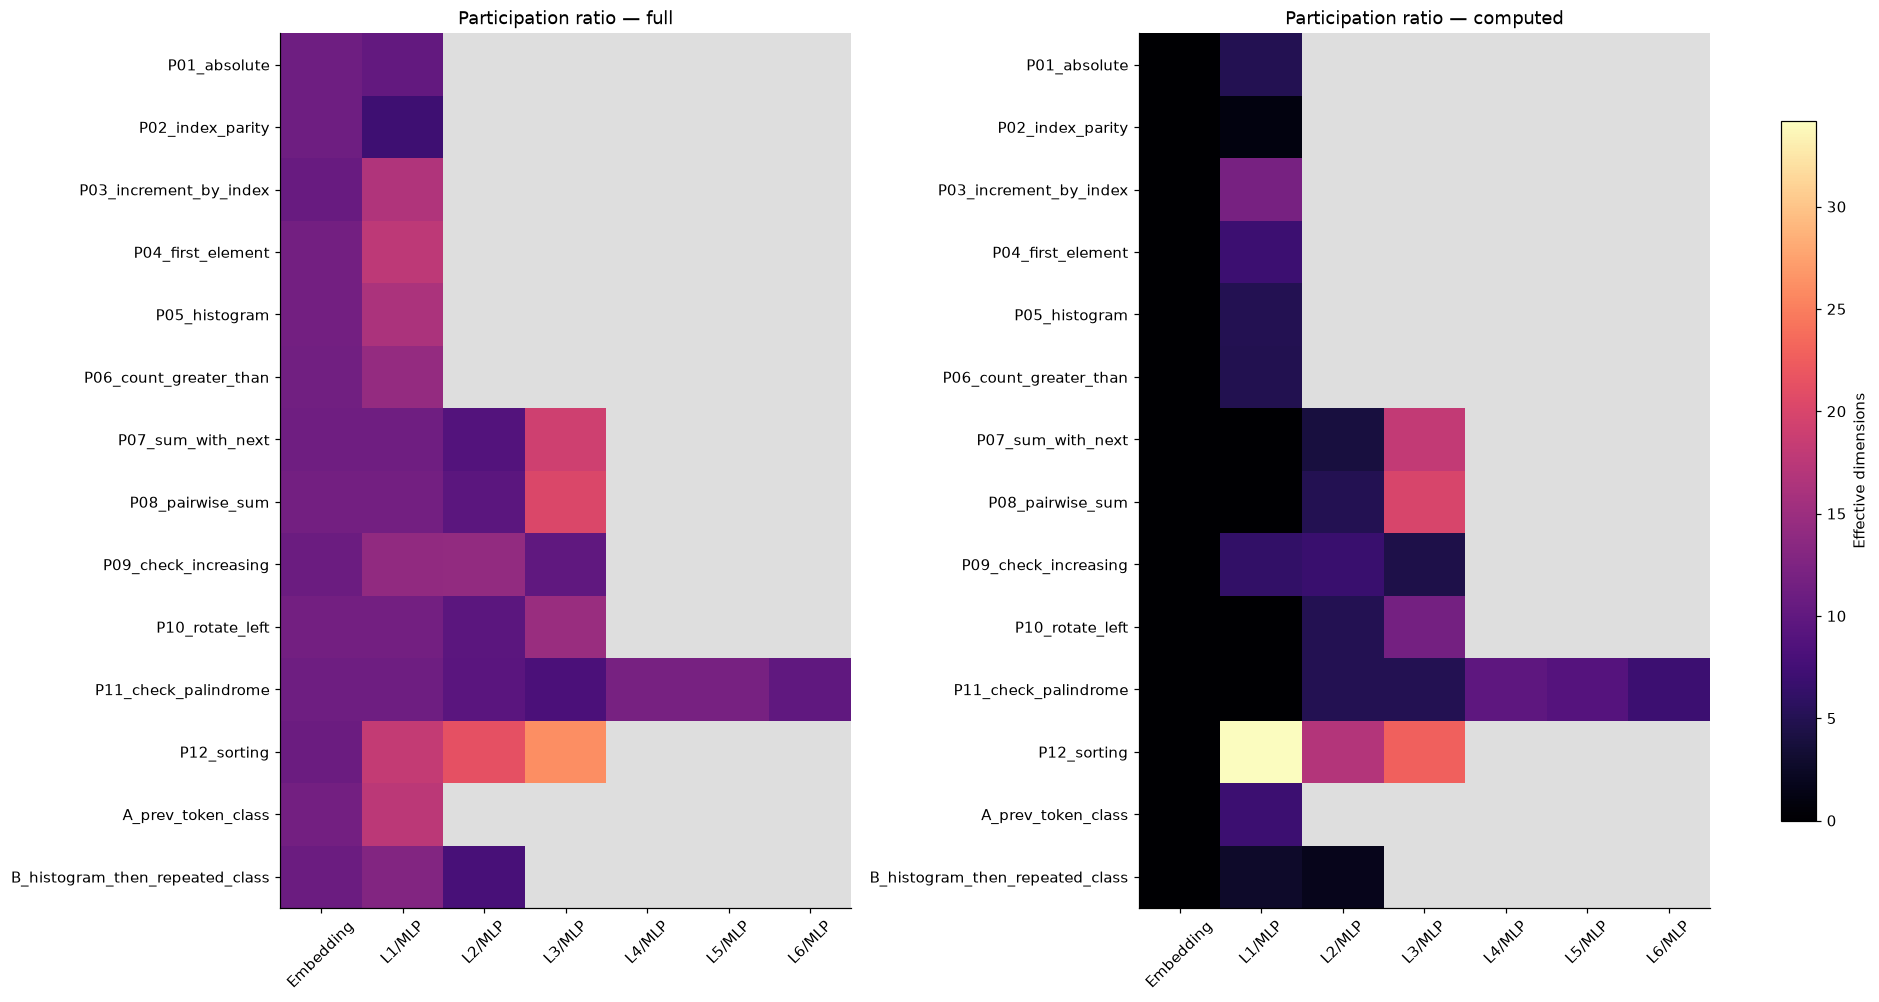

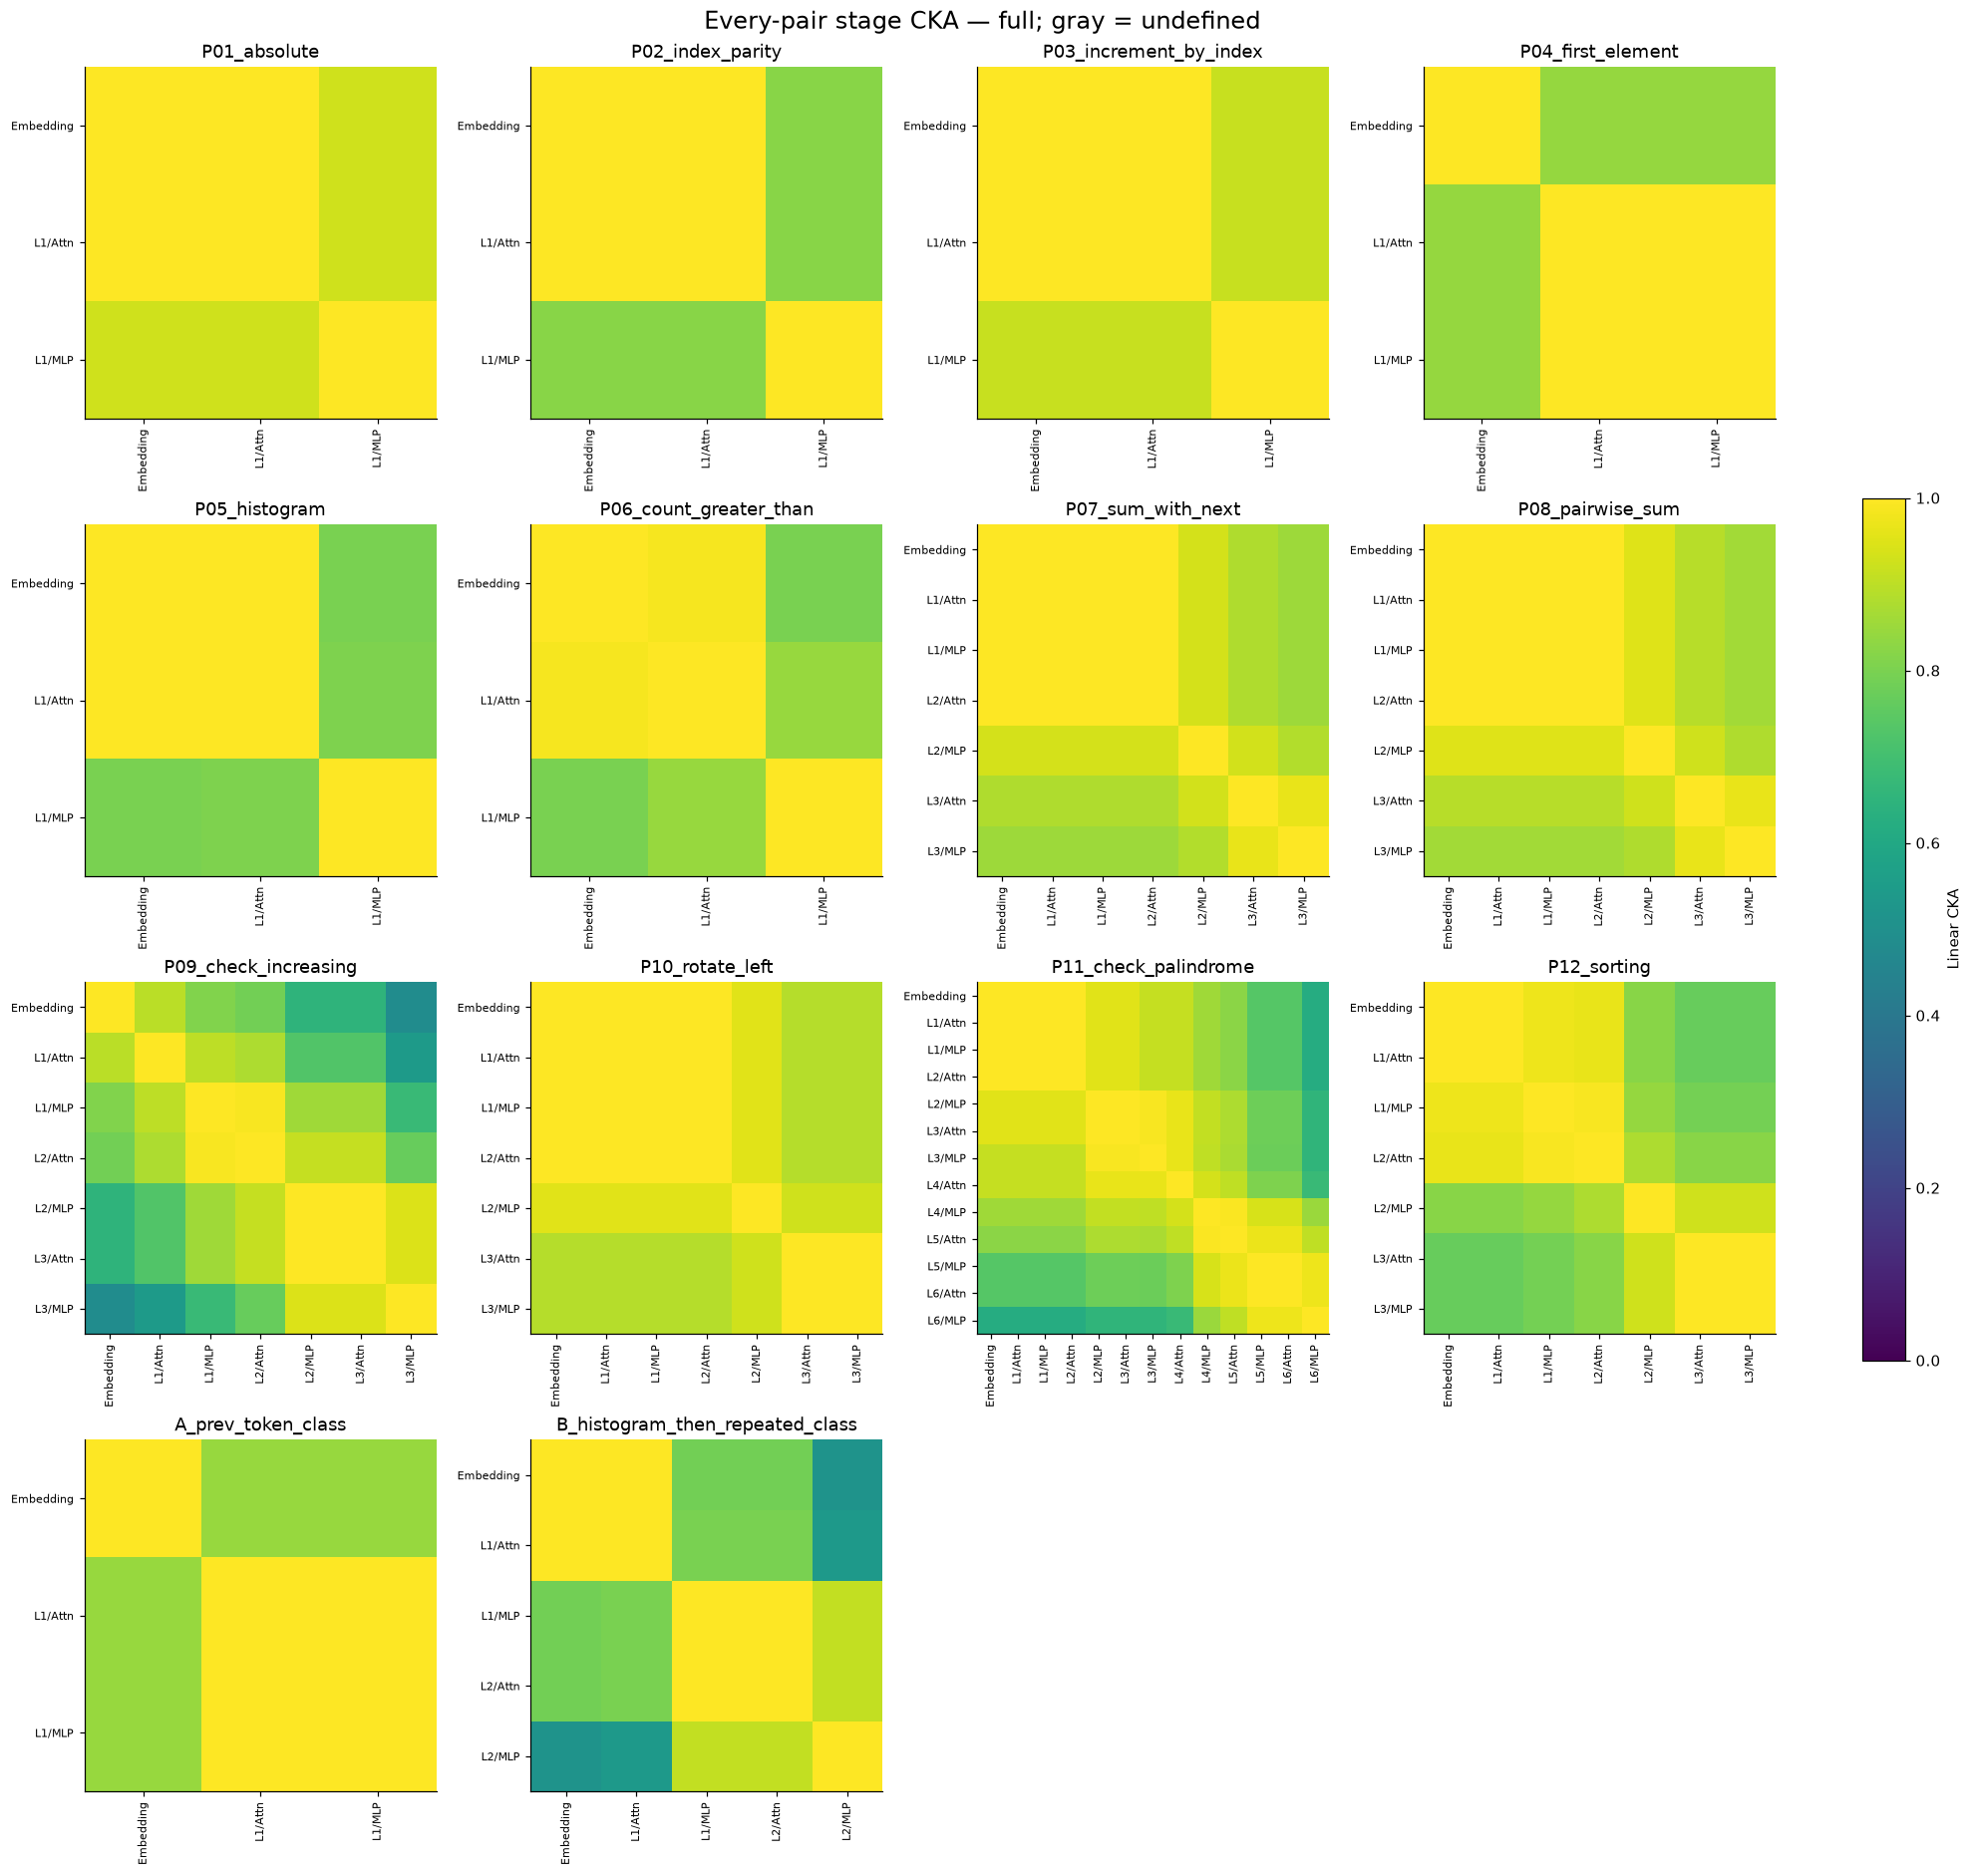

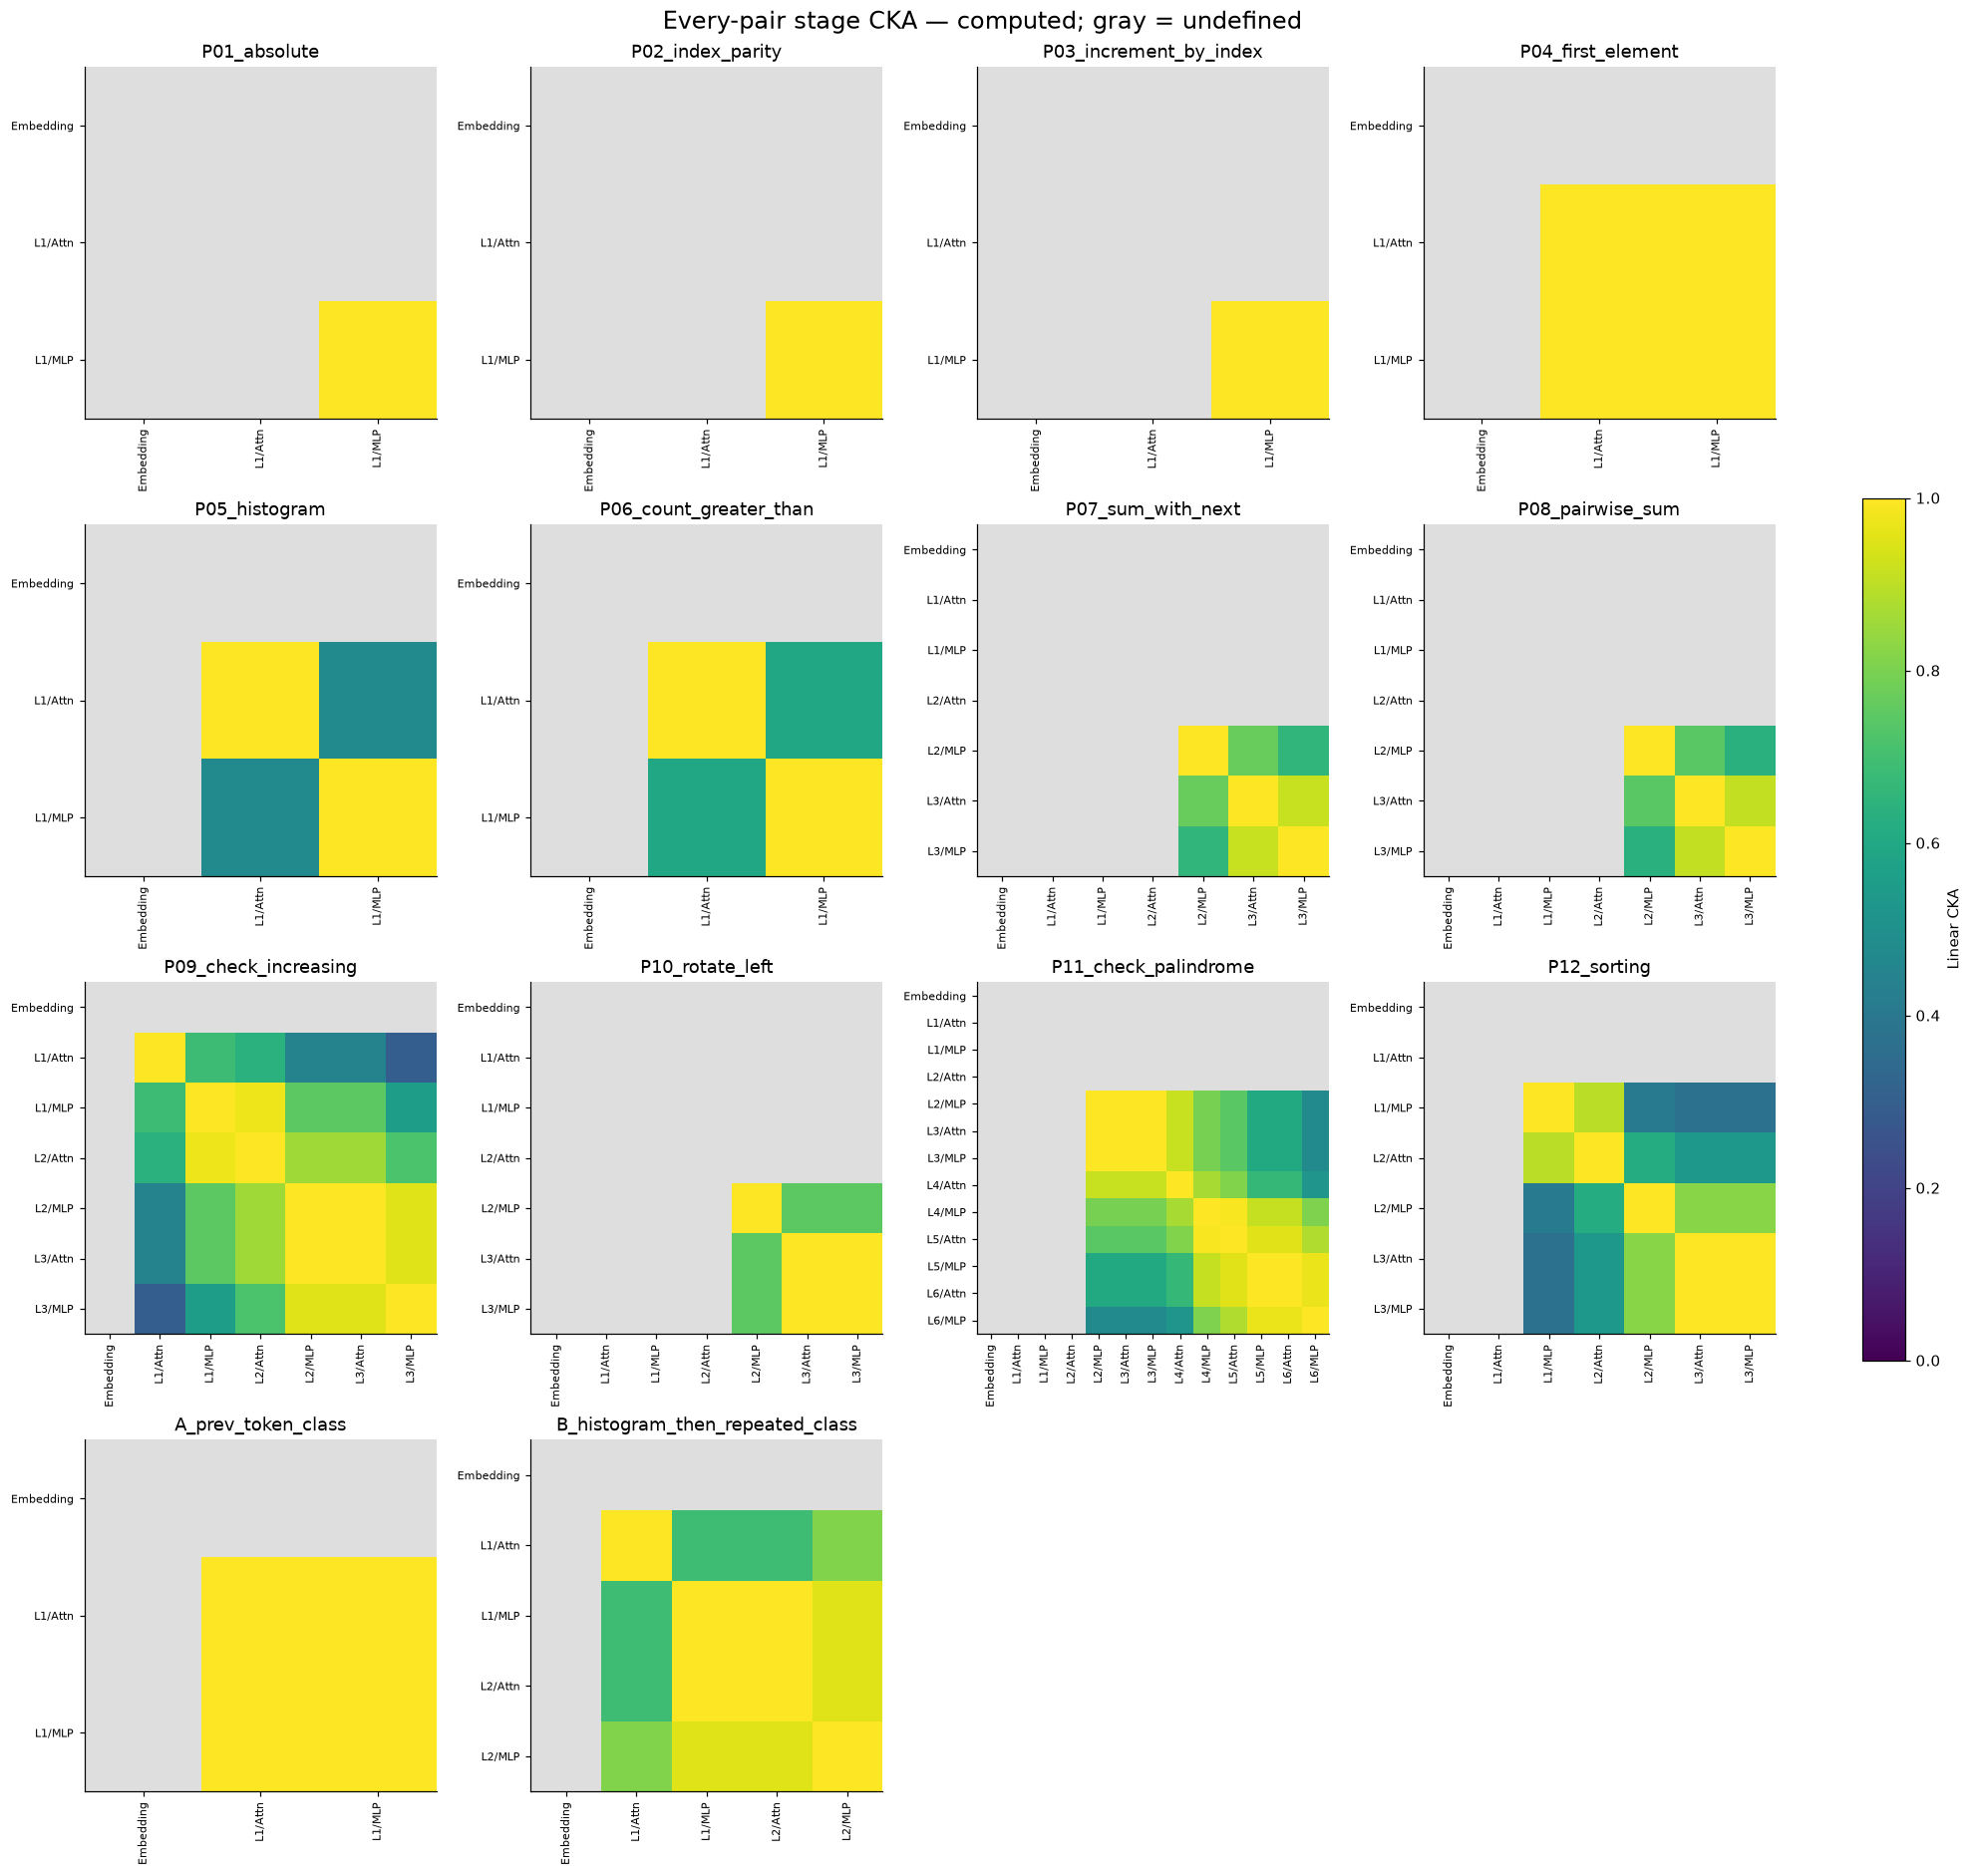

In [7]:
max_layers = max(model.model_config.num_layers for model in MODELS.values())
layer_labels = ["Embedding"] + [f"L{i}/MLP" for i in range(1, max_layers + 1)]
tables = {}
for view in ("full", "computed"):
    tables[view] = full_layers[full_layers.view == view].pivot(
        index="program", columns="stage", values="participation_ratio"
    ).reindex(index=list(PROGRAMS), columns=layer_labels)

fig, axes = plt.subplots(1, 2, figsize=(17, 9), constrained_layout=True)
cmap = plt.get_cmap("magma").copy()
cmap.set_bad("#dedede")
vmax = max(np.nanmax(table.to_numpy()) for table in tables.values())
for ax, (view, table) in zip(axes, tables.items()):
    im = ax.imshow(np.ma.masked_invalid(table.to_numpy()), aspect="auto", cmap=cmap, vmin=0, vmax=vmax)
    ax.set(title=f"Participation ratio — {view}", xticks=range(len(layer_labels)),
           xticklabels=layer_labels, yticks=range(len(PROGRAMS)), yticklabels=list(PROGRAMS))
    ax.tick_params(axis="x", rotation=45)
fig.colorbar(im, ax=axes, label="Effective dimensions", shrink=0.8)
fig.savefig(FIGURE_DIR / "participation_ratio_all_programs.png", bbox_inches="tight")
plt.show()

def cka_gallery(view):
    fig, axes = plt.subplots(4, 4, figsize=(18, 17), constrained_layout=True)
    for ax, name in zip(axes.flat, PROGRAMS):
        data = GEOMETRY[name][view]
        im = cka_image(ax, data["cka"], list(data["pca"]), name)
    for ax in list(axes.flat)[len(PROGRAMS):]:
        ax.axis("off")
    fig.colorbar(im, ax=list(axes.flat), shrink=0.5, label="Linear CKA")
    fig.suptitle(f"Every-pair stage CKA — {view}; gray = undefined", fontsize=16)
    fig.savefig(FIGURE_DIR / f"cka_gallery_{view}.png", bbox_inches="tight")
    plt.show()

cka_gallery("full")
cka_gallery("computed")

## 6. Which residual lanes vary, and how do tokens move?

Lane variance shows where variability appears. The trajectory plot fits one PCA
basis to all stages of a program and follows the selected target of one probe
in that shared coordinate system. This is a 2D projection of the full trajectory.

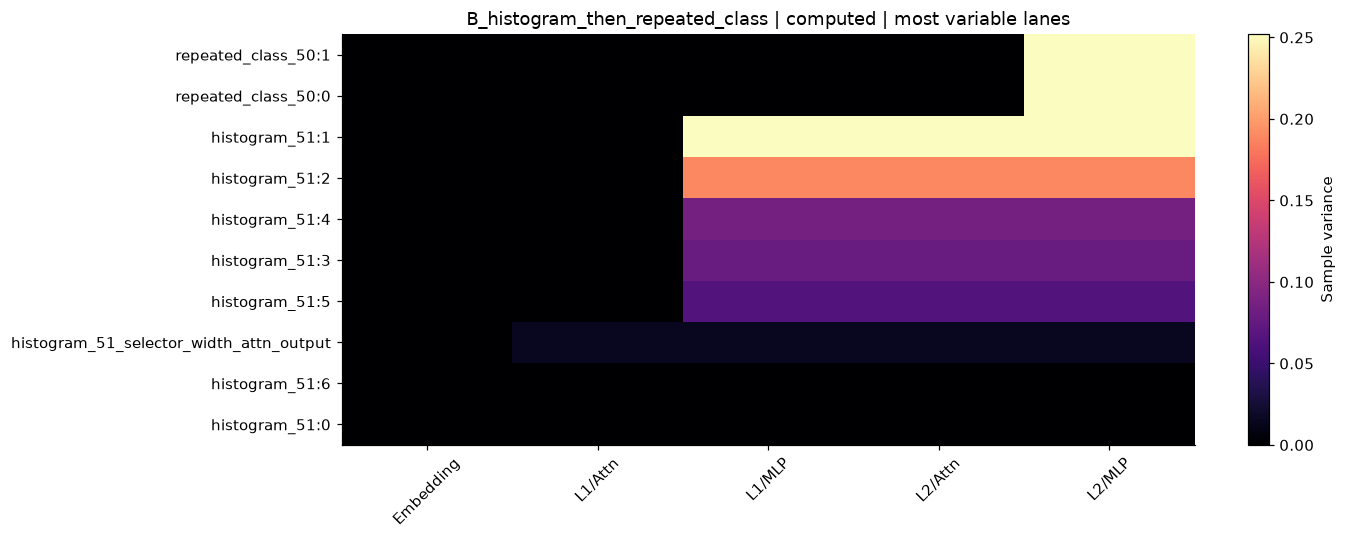

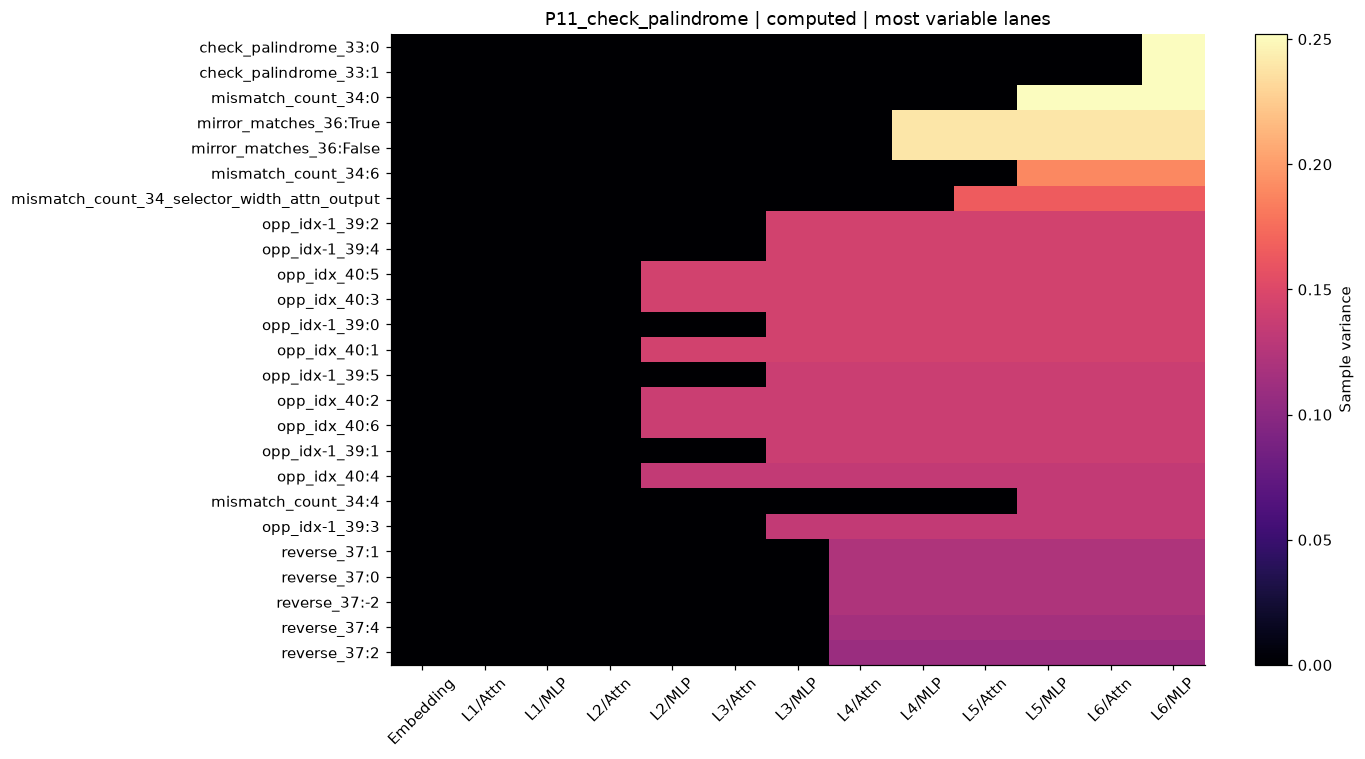

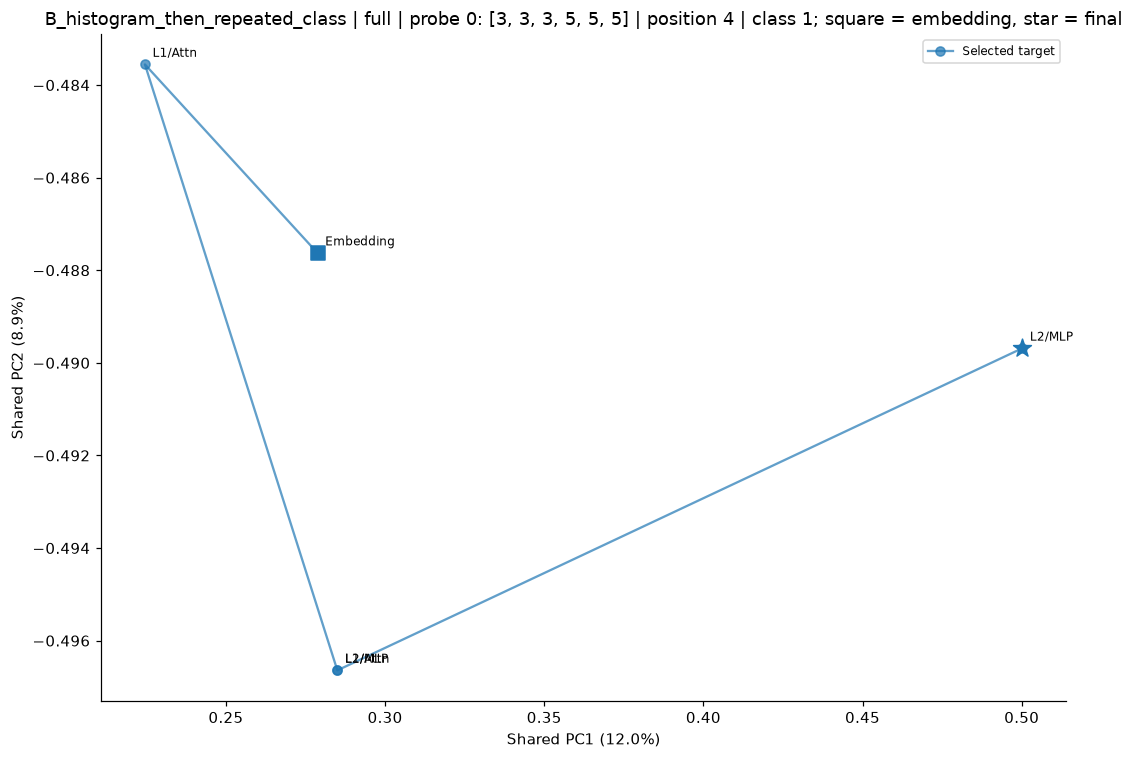

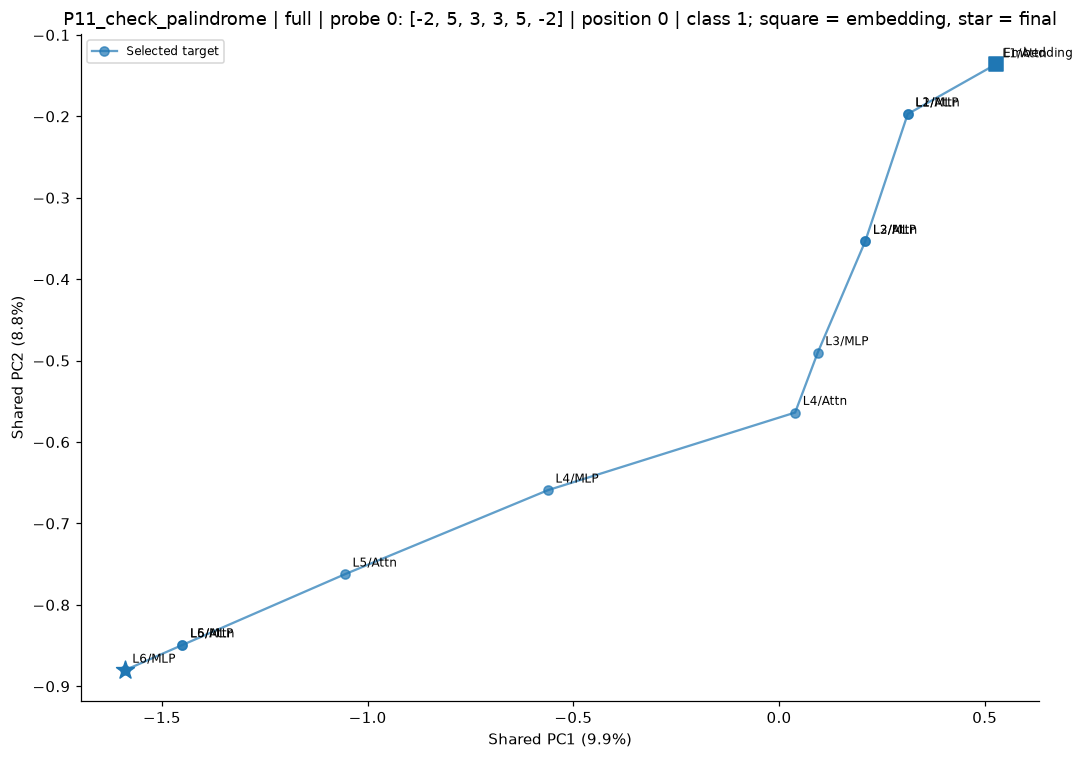

In [8]:
def lane_variance(program, view="computed", top=25):
    stages = list(ACTIVATIONS[program])
    variances = np.stack([representation(program, view, stage).var(axis=0, ddof=1)
                          for stage in stages])
    columns = VIEW_COLUMNS[program][view]
    selected = np.argsort(variances.max(axis=0))[::-1][:top]
    labels = [MODELS[program].residual_labels[columns[i]] for i in selected]
    fig, ax = plt.subplots(figsize=(13, max(5, 0.28 * len(selected))))
    im = ax.imshow(variances[:, selected].T, aspect="auto", cmap="magma")
    ax.set(xticks=range(len(stages)), xticklabels=stages,
           yticks=range(len(labels)), yticklabels=labels,
           title=f"{program} | {view} | most variable lanes")
    ax.tick_params(axis="x", rotation=45)
    fig.colorbar(im, ax=ax, label="Sample variance")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"lane_variance_{program}_{view}.png", bbox_inches="tight")
    plt.show()

def token_trajectories(program, probe_id=0, view="full"):
    stages = list(ACTIVATIONS[program])
    matrices = [representation(program, view, stage) for stage in stages]
    common = pca_profile(np.concatenate(matrices, axis=0))
    if not 0 <= probe_id < len(OBSERVATIONS[program]):
        raise ValueError("Unknown probe_id")
    row_ids = [probe_id]
    coordinates = np.stack([(X[row_ids] - common["mean"]) @ common["components"][:, :2]
                            for X in matrices])
    fig, ax = plt.subplots(figsize=(10, 7))
    for position in range(len(row_ids)):
        xy = coordinates[:, position]
        line, = ax.plot(xy[:, 0], xy[:, 1], "o-", alpha=0.7,
                        label="Selected target")
        ax.scatter(*xy[0], marker="s", s=80, color=line.get_color())
        ax.scatter(*xy[-1], marker="*", s=150, color=line.get_color())
    ratio = common["explained_variance_ratio"]
    target = OBSERVATIONS[program].iloc[probe_id]
    for index, stage in enumerate(stages):
        ax.annotate(stage, coordinates[index, 0], fontsize=8, xytext=(5, 5), textcoords="offset points")
    ax.set(title=f"{program} | {view} | probe {probe_id}: {PROBES[program][probe_id]}"
                 f" | position {target.position} | class {target.target_class}; square = embedding, star = final",
           xlabel=f"Shared PC1 ({ratio[0]:.1%})", ylabel=f"Shared PC2 ({ratio[1]:.1%})")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"trajectories_{program}_{view}_probe{probe_id}.png", bbox_inches="tight")
    plt.show()

lane_variance("B_histogram_then_repeated_class")
lane_variance("P11_check_palindrome")

token_trajectories("B_histogram_then_repeated_class", probe_id=0)
token_trajectories("P11_check_palindrome", probe_id=0)

## 7. Export the complete measurements

Exports include the probes, row metadata, model output labels, layer metrics,
every PCA spectrum, every stage-pair CKA matrix, and separate full-layer CKA
matrices. The manifest records model settings, residual labels, software versions,
the Tracr commit when available, and the included lanes in each view.

Full-layer matrices select `Embedding` and `Lk/MLP` from the all-stage matrices.
The numeric spectra archive uses NumPy arrays and can be loaded without pickle.

Dashboard: A_prev_token_class:   0%|          | 0/7 [00:00<?, ?step/s]

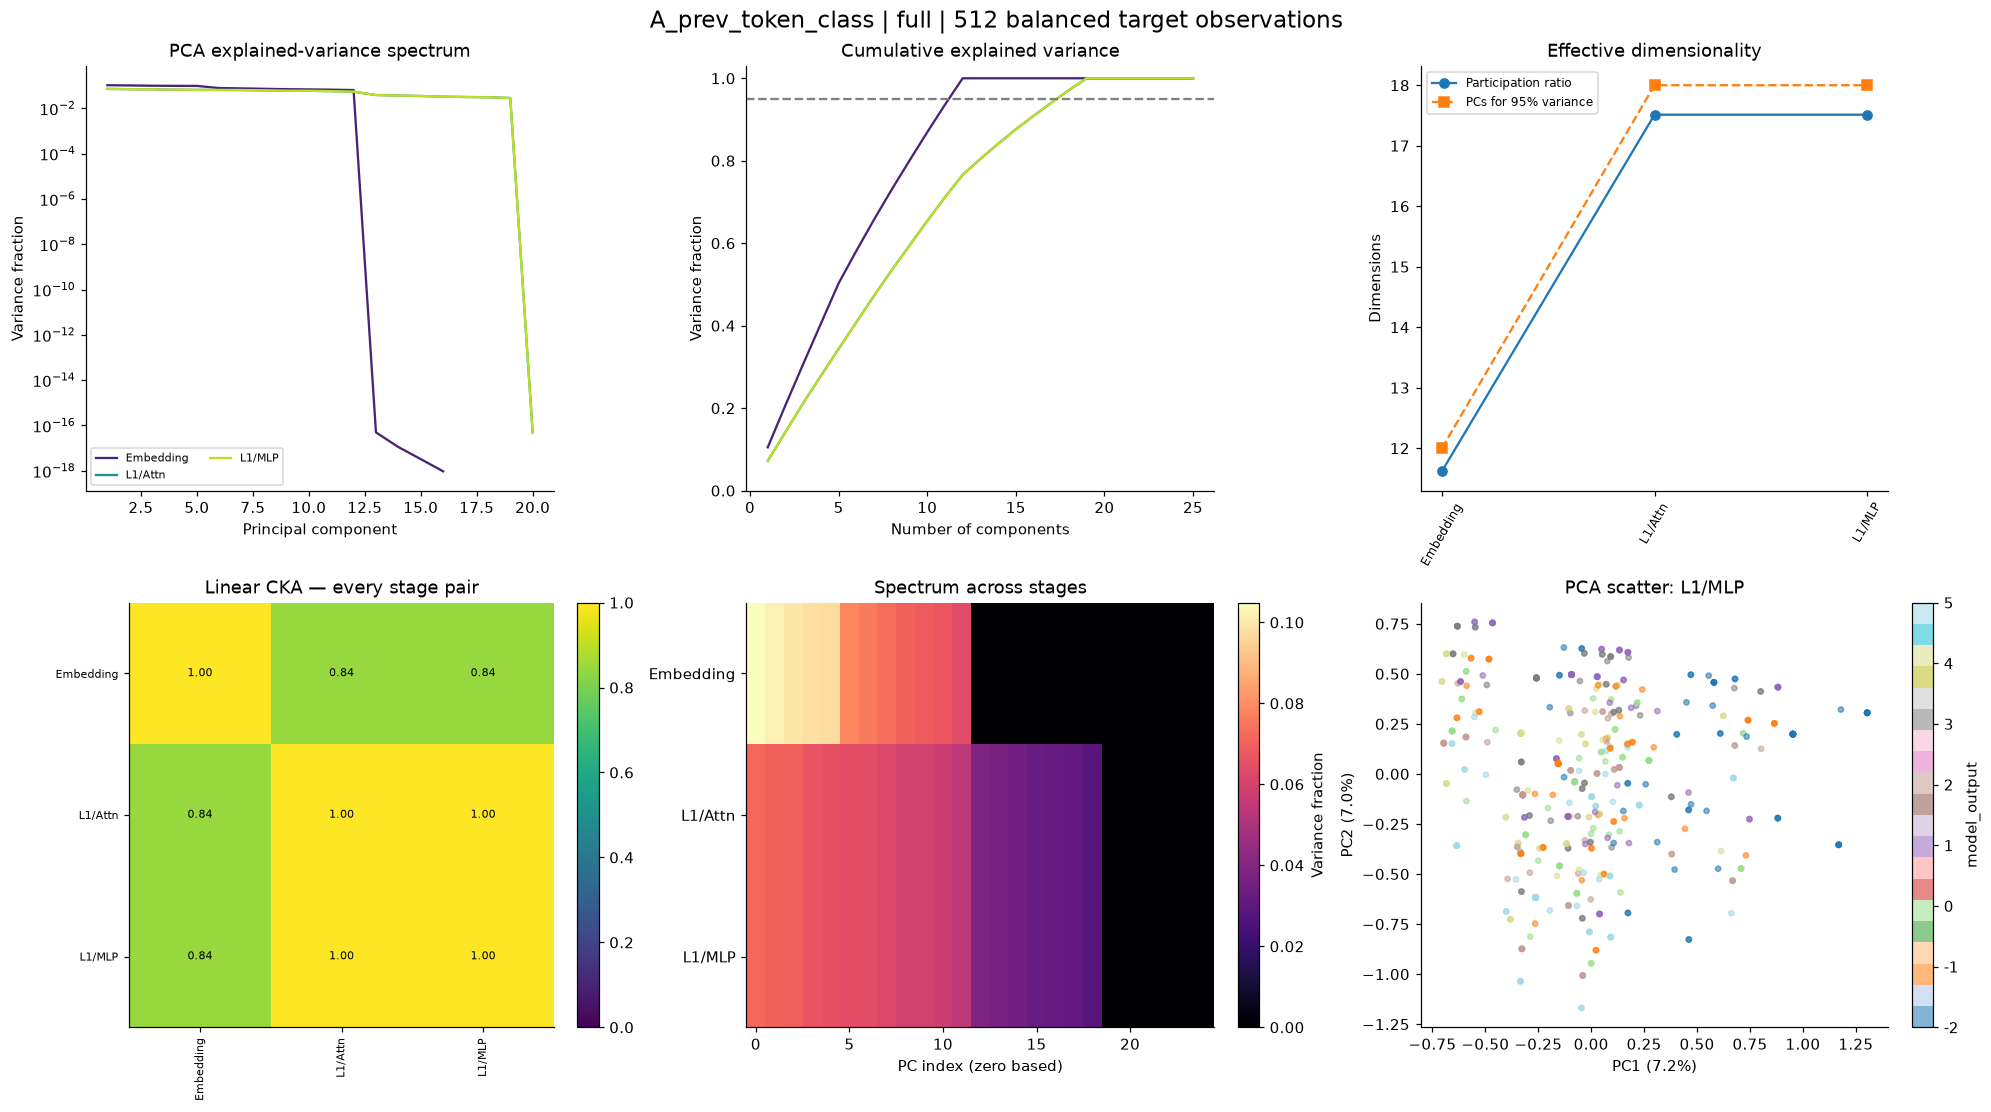

Dashboard rendered in 0.39s


Dashboard: A_prev_token_class:   0%|          | 0/7 [00:00<?, ?step/s]

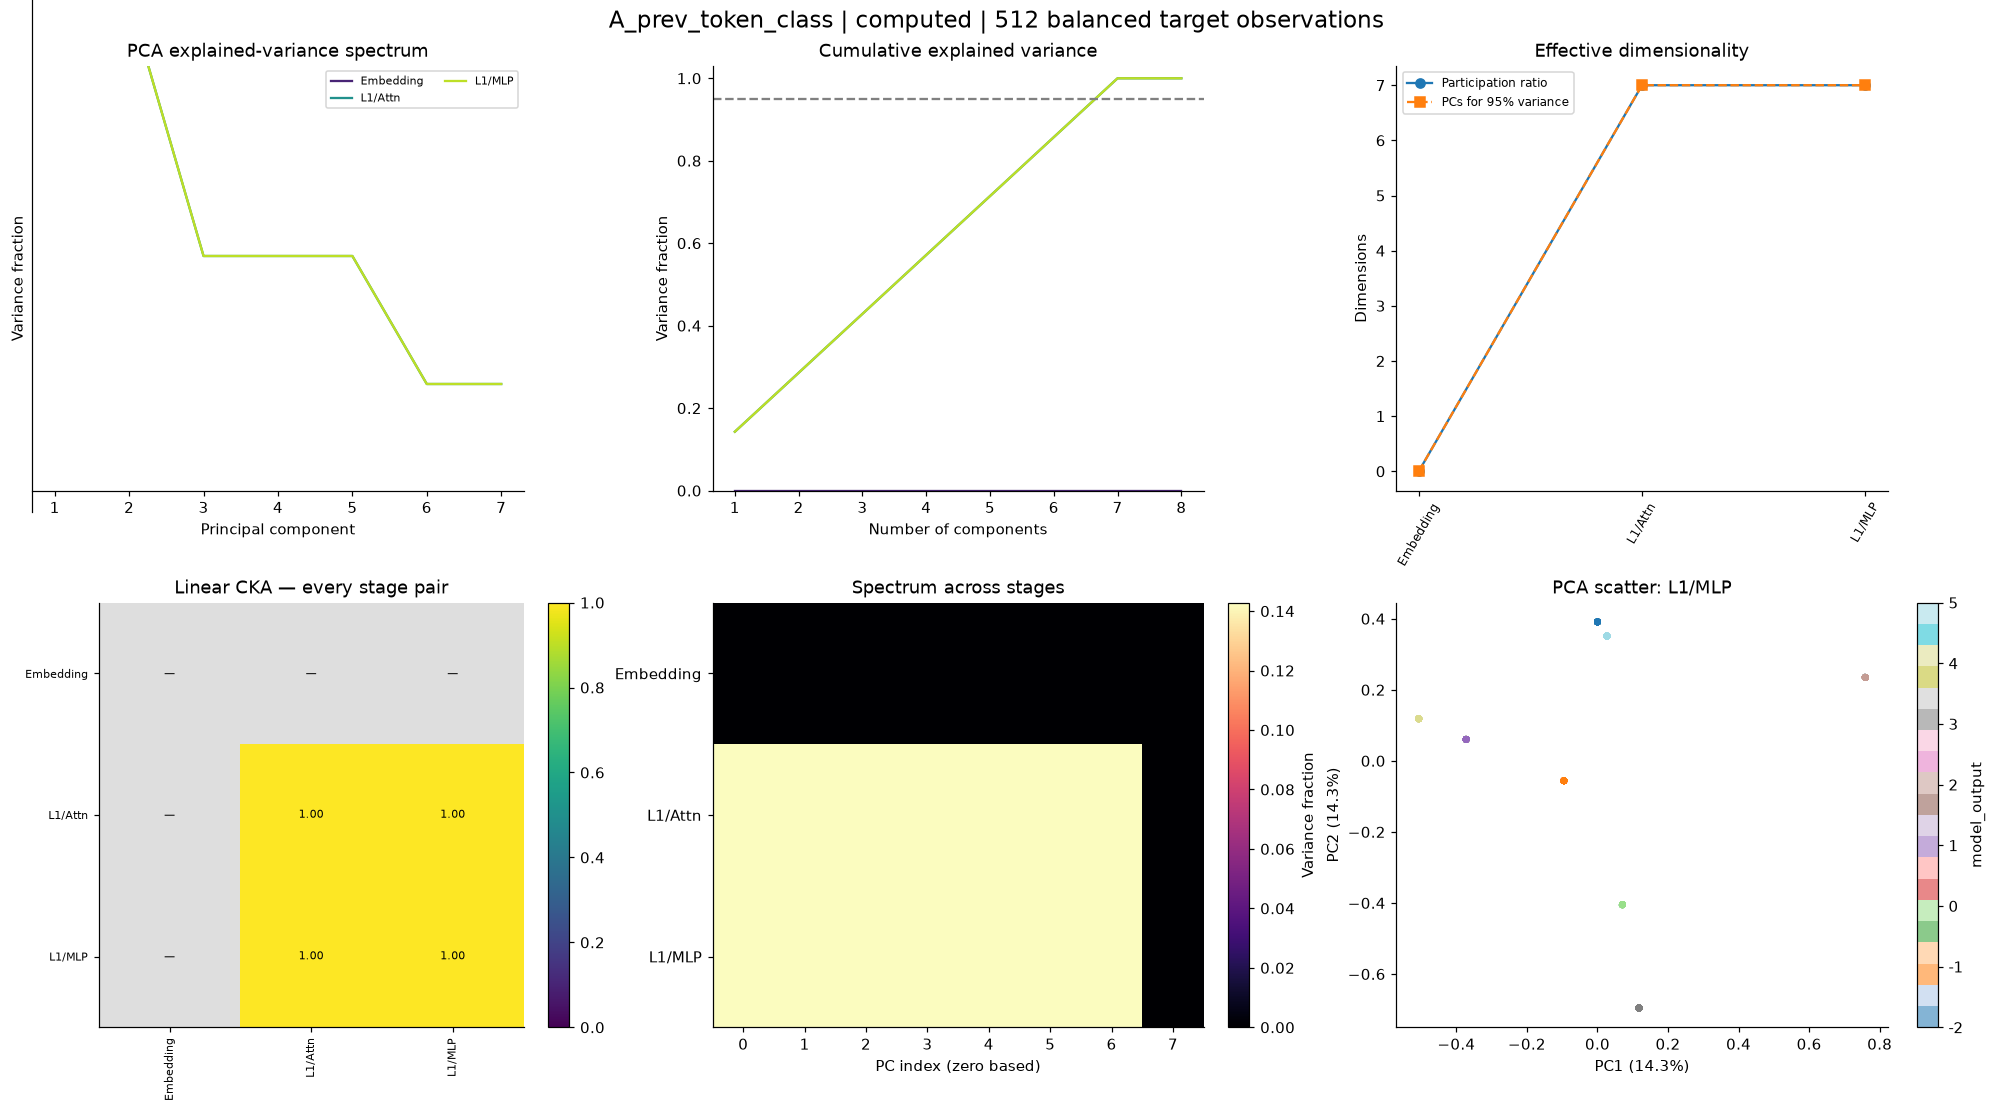

Dashboard rendered in 0.46s


Dashboard: B_histogram_then_repeated_class:   0%|          | 0/7 [00:00<?, ?step/s]

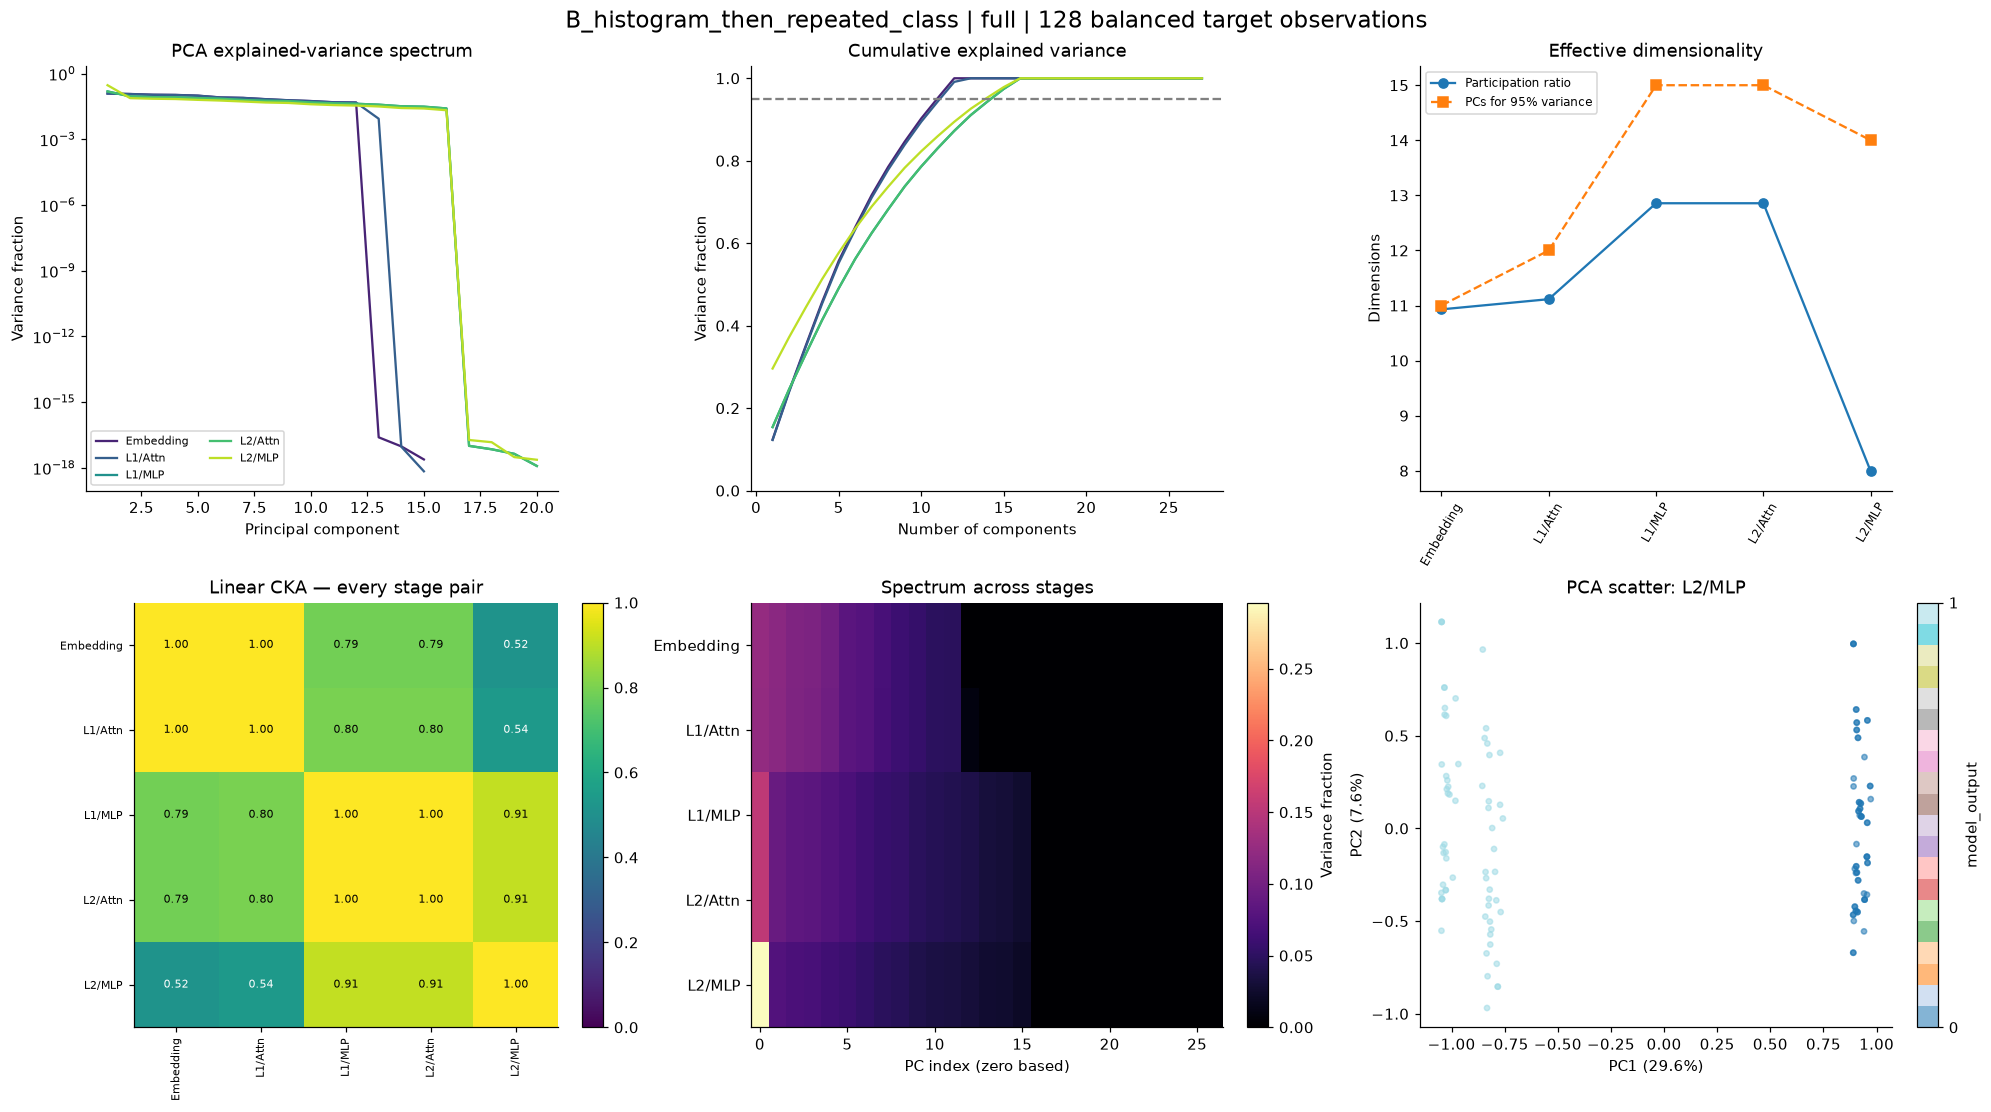

Dashboard rendered in 0.40s


Dashboard: B_histogram_then_repeated_class:   0%|          | 0/7 [00:00<?, ?step/s]

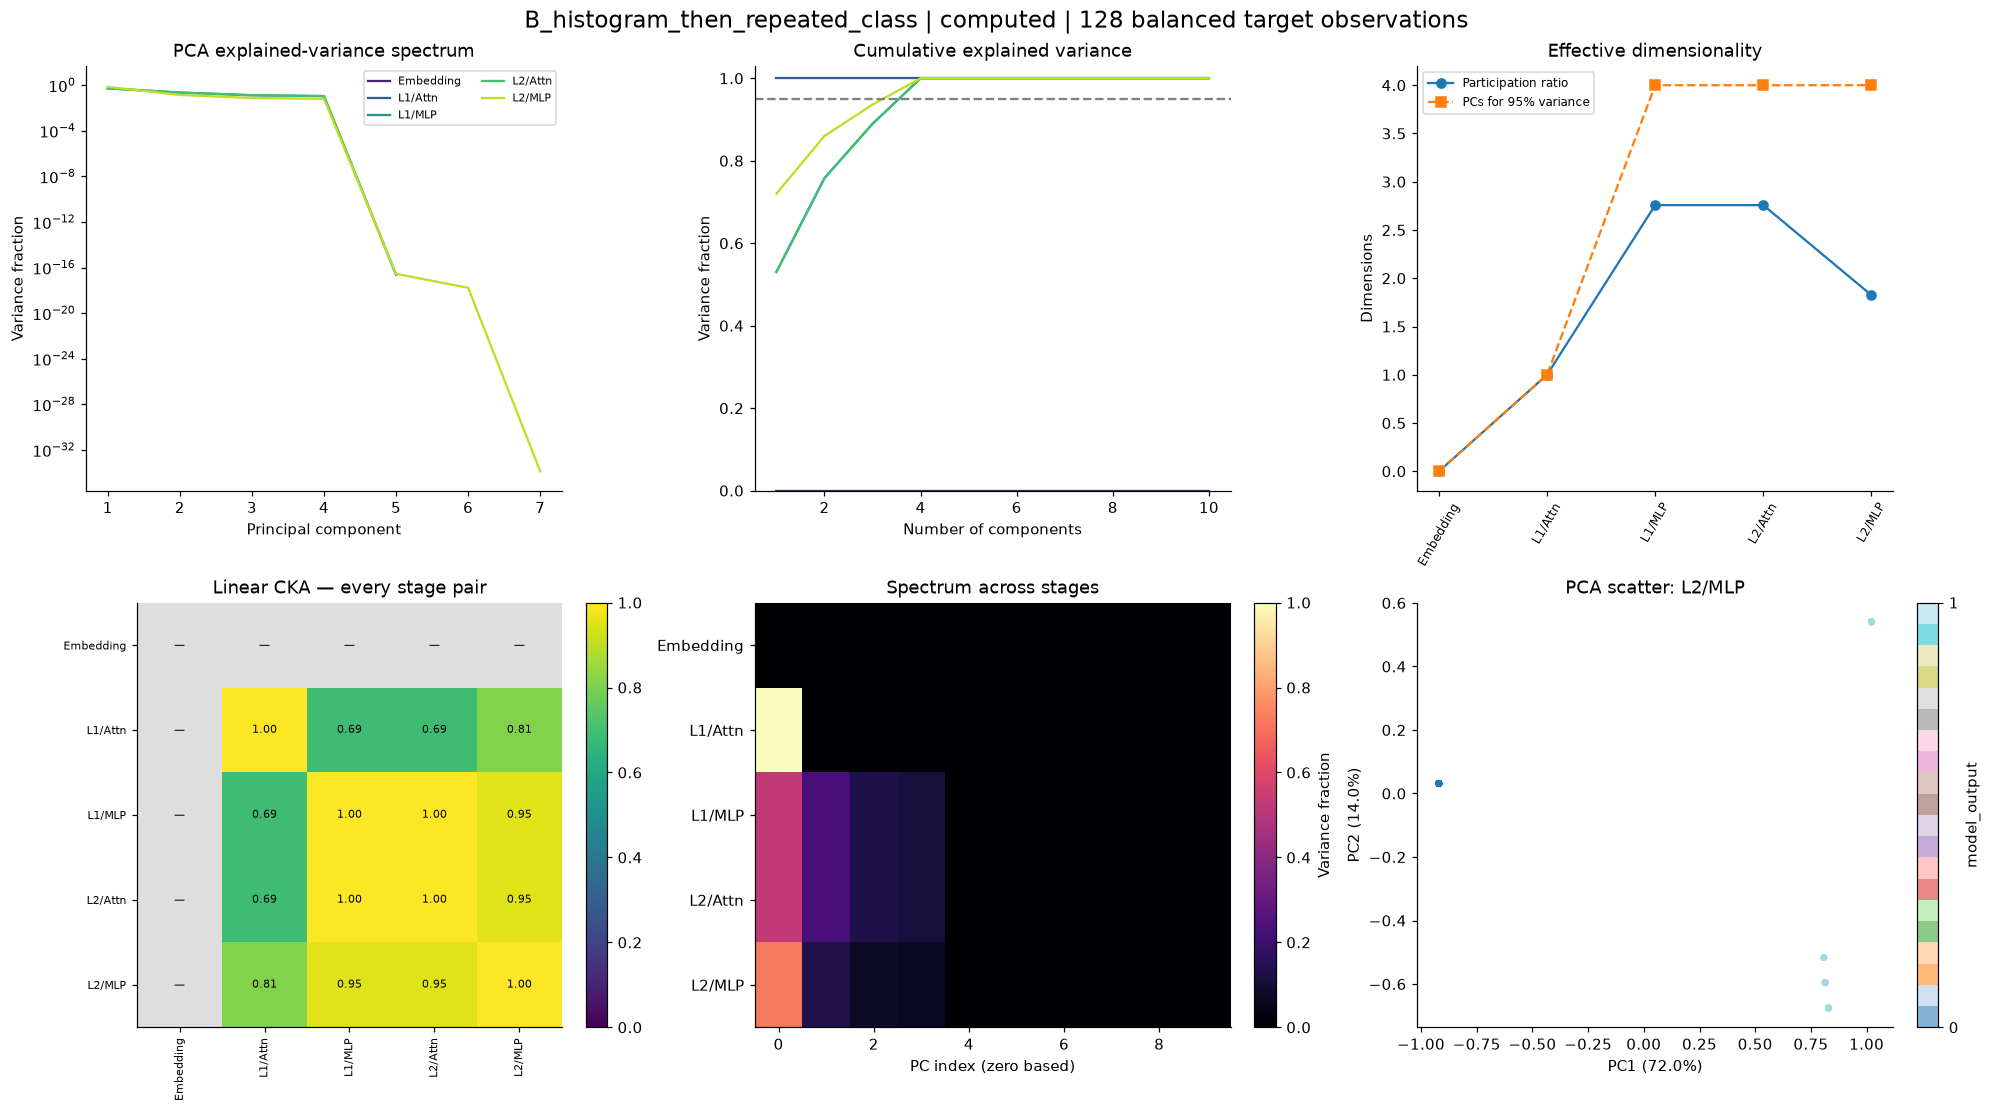

Dashboard rendered in 0.41s


Dashboard: P11_check_palindrome:   0%|          | 0/7 [00:00<?, ?step/s]

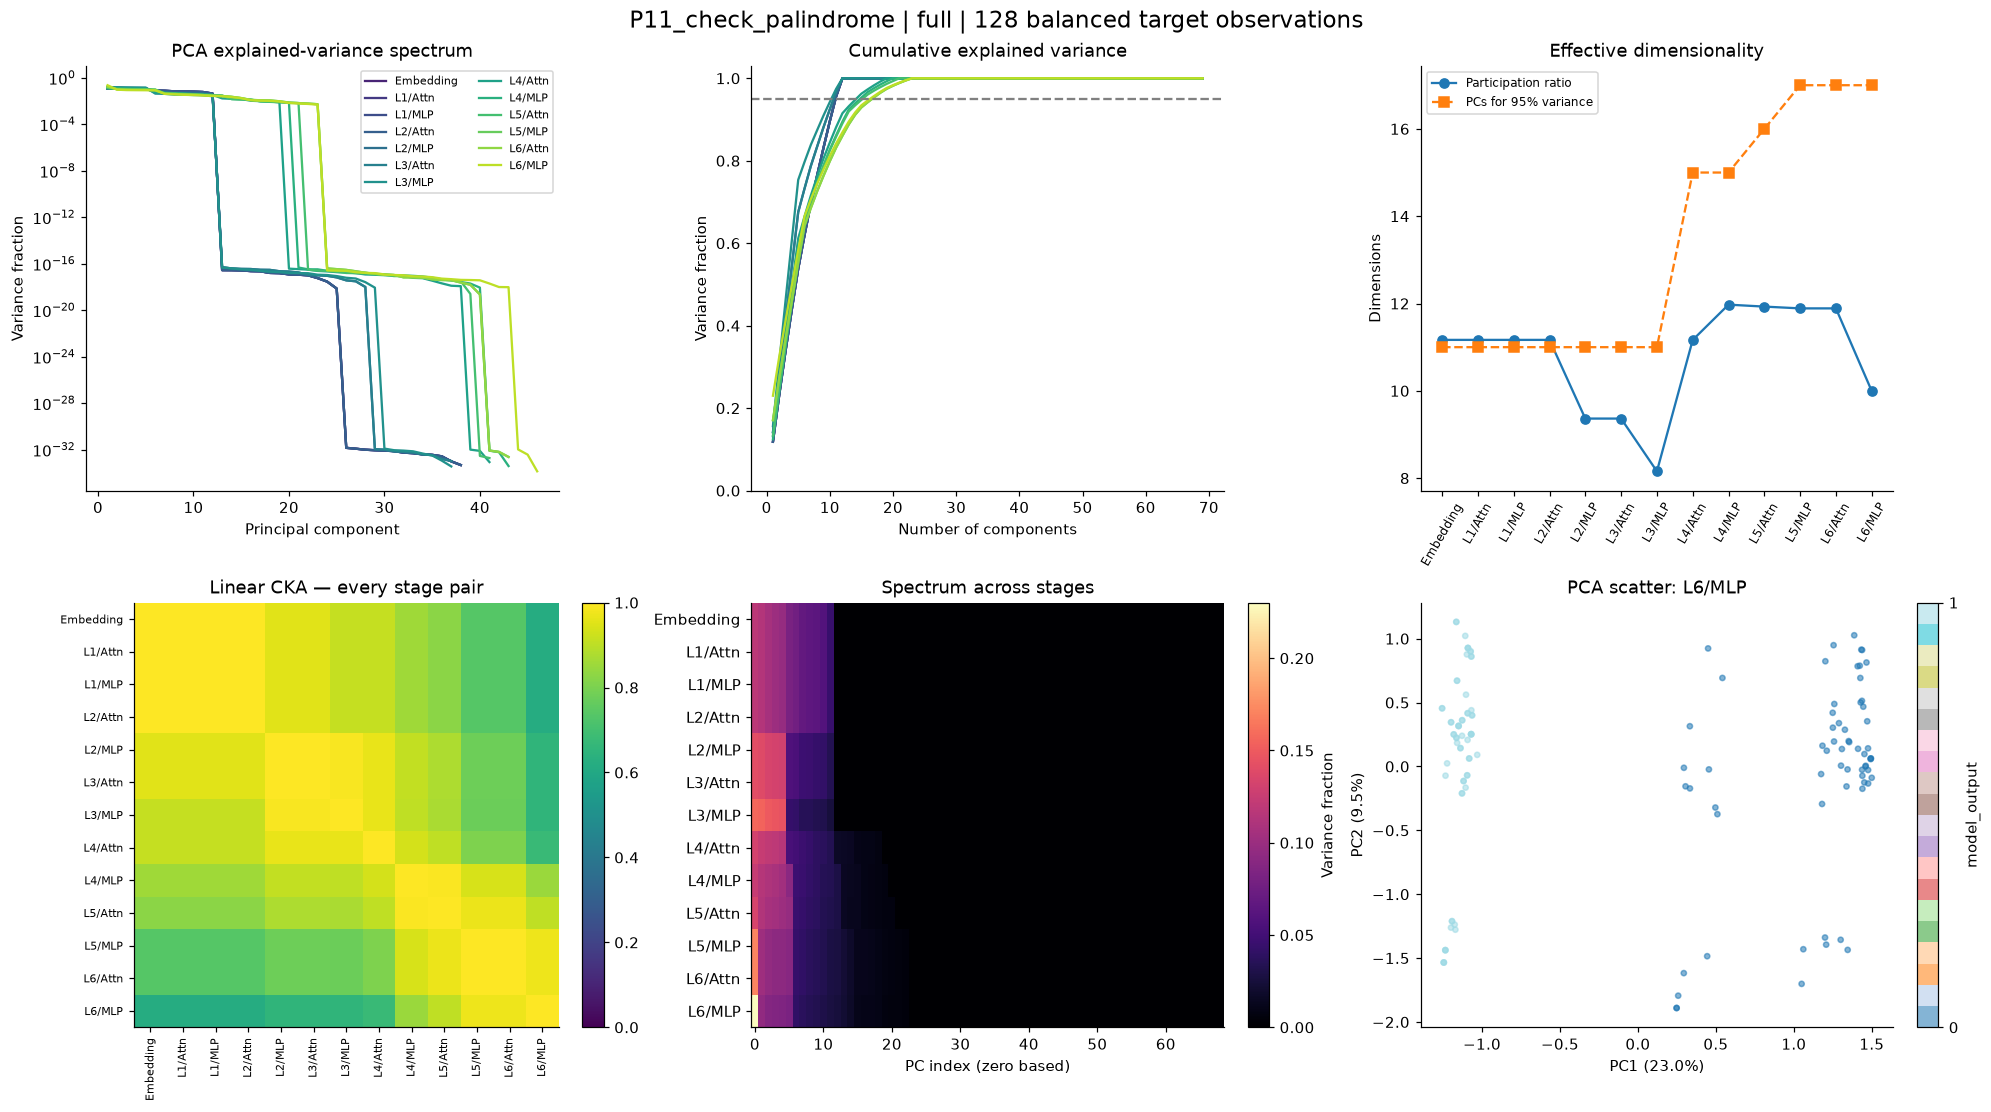

Dashboard rendered in 0.46s


Dashboard: P11_check_palindrome:   0%|          | 0/7 [00:00<?, ?step/s]

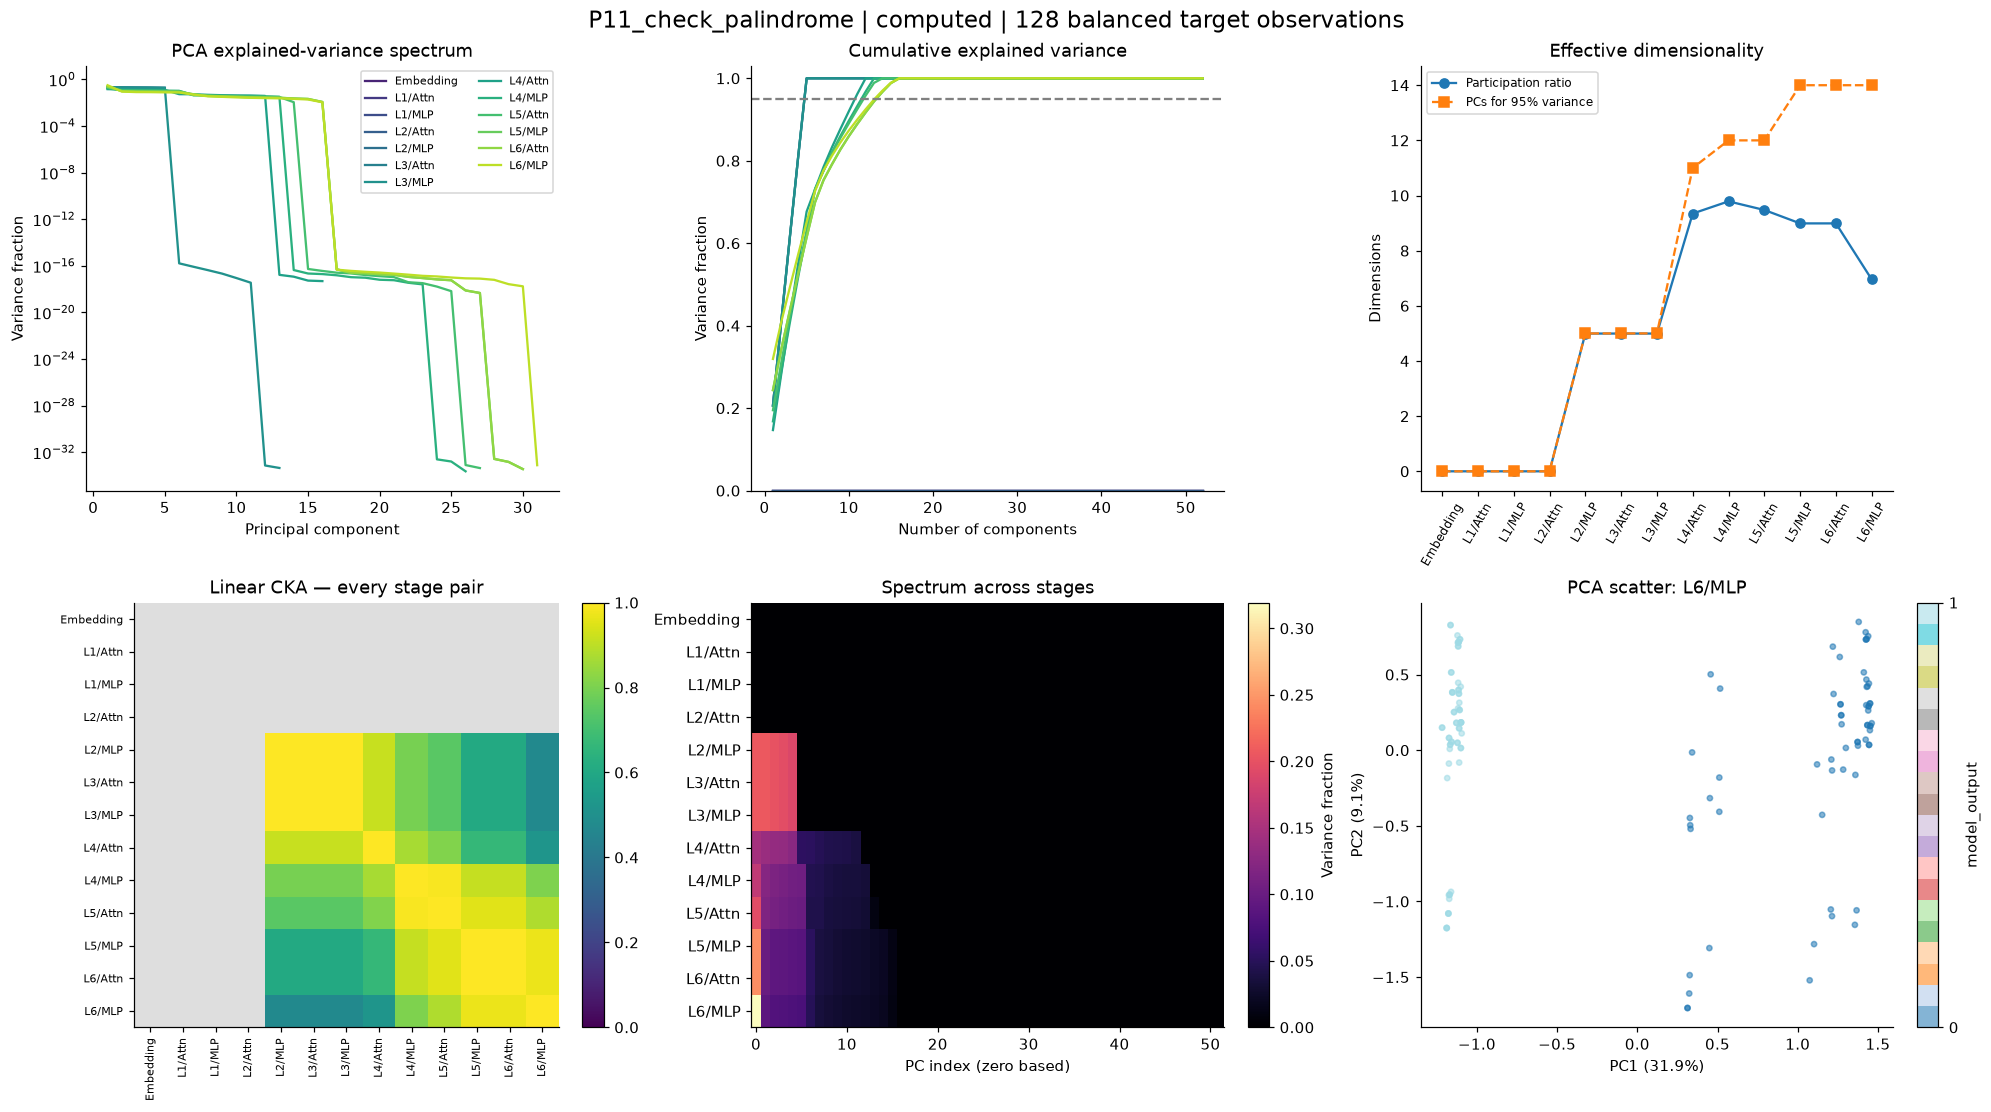

Dashboard rendered in 0.55s
Saved Step 3 measurements and figures to /Users/raghul/RaspFormer/notebooks/results/geometry/output_balanced_L6_seed42_n64


In [9]:
METRICS.to_csv(RUN_DIR / "layer_metrics.csv", index=False)
BALANCE_AUDIT.to_csv(RUN_DIR / "balance_audit.csv", index=False)
for name, table in OBSERVATIONS.items():
    table.assign(tokens=table.tokens.map(json.dumps)).to_csv(RUN_DIR / f"probes_{name}.csv", index=False)

spectra = {}
for name, views in GEOMETRY.items():
    for view, data in views.items():
        stages = list(data["pca"])
        pd.DataFrame(data["cka"], index=stages, columns=stages).to_csv(
            RUN_DIR / f"cka_{name}_{view}_all_stages.csv"
        )
        indices = [i for i, stage in enumerate(stages)
                   if stage == "Embedding" or stage.endswith("/MLP")]
        labels = [stages[i] for i in indices]
        pd.DataFrame(data["cka"][np.ix_(indices, indices)], index=labels, columns=labels).to_csv(
            RUN_DIR / f"cka_{name}_{view}_full_layers.csv"
        )
        for stage, profile in data["pca"].items():
            prefix = f"{name}__{view}__{stage.replace('/', '_')}"
            for field in ("eigenvalues", "explained_variance_ratio", "components", "mean"):
                spectra[f"{prefix}__{field}"] = profile[field]
np.savez_compressed(RUN_DIR / "pca_spectra.npz", **spectra)

direct_url = distribution("tracr").read_text("direct_url.json")
tracr_commit = (json.loads(direct_url).get("vcs_info", {}).get("commit_id")
                if direct_url else None)
manifest = {
    "seed": SEED, "probe_length": L, "samples_per_class": SAMPLES_PER_CLASS,
    "random_candidates": RANDOM_CANDIDATES, "structured_candidates": STRUCTURED_CANDIDATES,
    "candidate_sequences": len(CANDIDATES),
    "sampling": "separate program probes; equal observations per reachable output class; positions stratified; repeats retain weight",
    "observation": "one target token per probe; BOS excluded; no PAD; same row order within each program",
    "centering": "global feature centering; no whitening or standardization",
    "zero_variance": "PCA spectrum and PR recorded as zero; CKA undefined",
    "vocab": VOCAB, "max_seq_len": MAX_SEQ_LEN, "causal": CAUSAL,
    "mlp_exactness": MLP_EXACTNESS, "tracr_commit": tracr_commit,
    "python": sys.version.split()[0],
    "versions": {package: version(package) for package in
                 ("tracr", "numpy", "jax", "matplotlib", "pandas", "ipywidgets")},
    "models": {name: {
        "layers": model.model_config.num_layers, "residual_labels": model.residual_labels,
        "stages": list(ACTIVATIONS[name]), "observations": len(OBSERVATIONS[name]),
        "output_classes": EXPECTED_CLASSES[name],
        "view_columns": {view: columns.tolist() for view, columns in VIEW_COLUMNS[name].items()},
    } for name, model in MODELS.items()},
}
(RUN_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + chr(10))

# Export the dashboard for the focused progression and the deepest program.
for name in ("A_prev_token_class", "B_histogram_then_repeated_class", "P11_check_palindrome"):
    for view in ("full", "computed"):
        fig = dashboard(name, view)
        fig.savefig(FIGURE_DIR / f"dashboard_{name}_{view}.png", bbox_inches="tight")
        plt.close(fig)
print(f"Saved Step 3 measurements and figures to {RUN_DIR}")

## Reading the results

- A concentrated PCA spectrum means most observed variation lies in a few directions.
- Participation ratio summarizes the effective number of variance-carrying dimensions.
- Higher CKA means more similar centered linear geometry on these same observations.
- High full-residual CKA can reflect retained input lanes; compare the computed view.
- A gray computed-view CKA cell means a stage has no variance, not zero similarity.
- A zero-weight attention or MLP block may produce an identical residual and CKA of one.
- Constant directions disappear under centering. Fixed-length probes also hold length constant.
- A 2D scatter may omit substantial variance; read the PC1/PC2 percentages alongside it.
- Output classes are balanced over selected targets; other positions in a probe are context.
- Rare classes can contain repeated targets. Read unique-target counts alongside sample counts.
- Program probe distributions differ, so between-program differences can reflect sampling.

Use the six-panel dashboards for A and B to connect the geometry changes with
their first-write schedules. Use the palindrome example to inspect a deeper calculation.